<a href="https://colab.research.google.com/github/ManuAF-291196/Pruebas/blob/v1/Proyecto_CCS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Instalamos librerias
!pip install fuzzywuzzy
!pip install googletrans #instalamos la libreria de google tlanslator para traducir a español las variables categoricas
!pip install levenshtein #insatalamos levenshtein para agilizar la computacion de la comparacion de textos
!pip install skimpy

# Instalación de Streamlit, una biblioteca de Python para construir aplicaciones web interactivas.
!pip install -q streamlit

# Instalación de localtunnel, una herramienta para exponer servidores locales a la web
!npm install -q localtunnel

# Instalación de pyngrok, una biblioteca para integrar
#ngrok (herramienta para exponer servidores locales).
# https://ngrok.com/
!pip install pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6.17.1:
      Successfully uninstalled ipykernel-6.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipyke

In [2]:
#importamos las librerias
import pandas as pd #importamos pandas para analisis estadistico
import numpy as np #importamos numpy para reslizar operaciones matematicas
import matplotlib
import matplotlib.pyplot as plt #importamos pyplot de matplotlib para graficar
import seaborn as sns #importamos seaborn para graficos estadisticos
from googletrans import Translator, constants
from fuzzywuzzy import process
import statistics #importamos libreraria para analisis estadisticos
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from skimpy import skim



In [3]:
#Conectamos con google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#Definimos tema de los graficos
sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
#Cargamos Dataset1
##Variable con la ruta de datos
UrlDataset_Doe = "/content/drive/MyDrive/Energytalentotech/Dataset_1/CCS_Map_Data_Jan2023.xlsx"

proyectos_doe=pd.read_excel(UrlDataset_Doe, sheet_name="Map Data", index_col=0) #base de datos del doe

proyectos_doe

,Project Name,Company,Plant Name,Storage and/or Capture,Overall Status,Plant Status,Project Phase,Country Location,State Location,Specific Site Location,...,Exact,Paper,Regional Partnership,Other,Scope Code,Scope Name,State Code,Status Code,Project Type,Injection Unit Base Code
Project ID,,,,,,,,,,,,,,,,,,,,,
387,Lost Cabin Gas Plant CCS Project,"ConocoPhillips, Denbury",Lost Cabin Gas Plant,Capture,NaN,NaN,Operational,United States,Wyoming,Lost Cabin,...,Exact,False,False,The Lost Creek Gas Plant began separating and ...,Nat,National,WY,NaN,Capture,NaN
390,Getica CCS Demonstration Project,Getica CCS Project Company,Turceni Power Station (now part of Oltenia Ene...,Capture and Storage,Hold,Existing,Planning,Romania,Gorj County,Turceni,...,Exact,False,False,NaN,Int,International,Gc RO,HLD,CCS,NaN
395,Project Tundra Carbon Capture System,Minnkota Power Cooperative,Milton R. Young Station,Capture,Active,Existing,Engineering design,United States,North Dakota,"Hensler, North Dakota",...,Exact,False,False,NaN,Nat,National,ND,ACT,Capture,NaN
396,North Dakota CarbonSAFE Phase III: Site Charac...,Energy & Environmental Research Center - Unive...,Milton R. Young Station,Storage,Active,Existing,Site Characterization,United States,North Dakota,"East Oliver, North Dakota",...,Exact,False,True,NaN,Nat,National,ND,ACT,Storage,T/D
397,Front End Engineering Design of Linde-BASF Adv...,Southern Company,Plant Daniel Units 3 and 4,Capture,Active,Existing,Engineering design,United States,Mississippi,"Moss Point, MS",...,Exact,False,False,capture technology: OASE® blue solvent,Nat,National,MS,ACT,Capture,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,Axe Seine/Normandy decarbonization project,Air Liquide,NaN,Plan,Potential,NaN,Memorandum of Understanding,France,NaN,Axe Seine/Normandy,...,Approximate,False,False,NaN,Int,International,NaN,POT,Plan,NaN
495,CCS with Elkem Iceland,Aker Carbon Capture,Elkem Iceland ferrosilicon plant,Capture and Storage,Potential,NaN,Memorandum of Understanding,Iceland,NaN,Akranes,...,Exact,False,False,NaN,Int,International,NaN,POT,CCS,NaN
496,Blue Planet's pilot plant,Blue Planet Systems Corporation,Blue Planet pilot plant,Capture and Storage,Active,NaN,Plant Design,United States,California,"Pittsburg, California",...,Exact,False,False,NaN,Nat,National,CA,ACT,CCS,NaN


In [ ]:
proyectos_doe

,Project Name,Company,Plant Name,Storage and/or Capture,Overall Status,Plant Status,Project Phase,Country Location,State Location,Specific Site Location,...,Exact,Paper,Regional Partnership,Other,Scope Code,Scope Name,State Code,Status Code,Project Type,Injection Unit Base Code
Project ID,,,,,,,,,,,,,,,,,,,,,
387,Lost Cabin Gas Plant CCS Project,"ConocoPhillips, Denbury",Lost Cabin Gas Plant,Capture,NaN,NaN,Operational,United States,Wyoming,Lost Cabin,...,Exact,False,False,The Lost Creek Gas Plant began separating and ...,Nat,National,WY,NaN,Capture,NaN
390,Getica CCS Demonstration Project,Getica CCS Project Company,Turceni Power Station (now part of Oltenia Ene...,Capture and Storage,Hold,Existing,Planning,Romania,Gorj County,Turceni,...,Exact,False,False,NaN,Int,International,Gc RO,HLD,CCS,NaN
395,Project Tundra Carbon Capture System,Minnkota Power Cooperative,Milton R. Young Station,Capture,Active,Existing,Engineering design,United States,North Dakota,"Hensler, North Dakota",...,Exact,False,False,NaN,Nat,National,ND,ACT,Capture,NaN
396,North Dakota CarbonSAFE Phase III: Site Charac...,Energy & Environmental Research Center - Unive...,Milton R. Young Station,Storage,Active,Existing,Site Characterization,United States,North Dakota,"East Oliver, North Dakota",...,Exact,False,True,NaN,Nat,National,ND,ACT,Storage,T/D
397,Front End Engineering Design of Linde-BASF Adv...,Southern Company,Plant Daniel Units 3 and 4,Capture,Active,Existing,Engineering design,United States,Mississippi,"Moss Point, MS",...,Exact,False,False,capture technology: OASE® blue solvent,Nat,National,MS,ACT,Capture,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,Axe Seine/Normandy decarbonization project,Air Liquide,NaN,Plan,Potential,NaN,Memorandum of Understanding,France,NaN,Axe Seine/Normandy,...,Approximate,False,False,NaN,Int,International,NaN,POT,Plan,NaN
495,CCS with Elkem Iceland,Aker Carbon Capture,Elkem Iceland ferrosilicon plant,Capture and Storage,Potential,NaN,Memorandum of Understanding,Iceland,NaN,Akranes,...,Exact,False,False,NaN,Int,International,NaN,POT,CCS,NaN
496,Blue Planet's pilot plant,Blue Planet Systems Corporation,Blue Planet pilot plant,Capture and Storage,Active,NaN,Plant Design,United States,California,"Pittsburg, California",...,Exact,False,False,NaN,Nat,National,CA,ACT,CCS,NaN


In [5]:
#Cargamos los datos
#Datset2
proyectos_iea=pd.read_excel("/content/drive/MyDrive/Energytalentotech/Dataset_2/IEA_CCUS_Projects_Database_2024.xlsx", sheet_name="CCUS_Projects_Database", index_col=1)


In [ ]:
#Informacion Preliminar DataSet1
pd.unique(proyectos_doe["Project Type"])
pd.unique(proyectos_doe['Overall Status'])
proyectos_doe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417 entries, 387 to 498
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   Project Name                            417 non-null    object        
 1   Company                                 416 non-null    object        
 2   Plant Name                              349 non-null    object        
 3   Storage and/or Capture                  404 non-null    object        
 4   Overall Status                          407 non-null    object        
 5   Plant Status                            283 non-null    object        
 6   Project Phase                           346 non-null    object        
 7   Country Location                        410 non-null    object        
 8   State Location                          356 non-null    object        
 9   Specific Site Location                  399 non-null    o

In [ ]:

##Limpieza Dataset1
##Eliminamos las columnas con informacion redundante o sin utilidad
##Lista de columnas a excluir

ColumnasExcluir = ["Plant Name","State Location","Specific Site Location"
,"Size or Capture Amount/unit base power","Power or Capture Unit"
,"Power or Capture Unit Base Code","Combustion / Separation","Capture Technology"
,"Project Summary","Project Date","Cost","Currency Name"
,"Project Information Webpage","Latitude","Longitude","Continent Code"
,"Country Code","District Code","DOE Support","Exact Checkbox","Exact"
,"Paper","Regional Partnership","Other","Scope Code","Scope Name","State Code"
,"Status Code","Injection Unit Base Code"
,"Project Name","Storage and/or Capture","Plant Status","Project Phase"
,"Company","Continent Name"]

if isinstance(proyectos_doe, pd.DataFrame) and len(proyectos_doe.columns) > 0:
  if("Company" in proyectos_doe.columns):
    proyectos_doe.drop(labels=ColumnasExcluir, axis=1, inplace=True)

#hacemos remplazo de un valor con error de digitacion
proyectos_doe['Project Type'].replace(to_replace="CCUST", value="CCUS", inplace=True)

##Equivalencias con Dataset2 de tipos d eproyect

proyectos_doe['Project Type'].replace(to_replace="CCUS", value="Full Chain", inplace=True)
proyectos_doe['Project Type'].replace(to_replace="CTS", value="T&S", inplace=True)
proyectos_doe['Project Type'].replace(to_replace="TS", value="T&S", inplace=True)
proyectos_doe['Project Type'].replace(to_replace="THS", value="T&S", inplace=True)

proyectos_doe['Project Type'].replace(to_replace="Tk", value="Transport", inplace=True)
proyectos_doe['Project Type'].replace(to_replace="Tk", value="Transport", inplace=True)

proyectos_doe['Project Type'].replace(to_replace="DACU", value="CCU", inplace=True)
proyectos_doe['Project Type'].replace(to_replace="CU", value="CCU", inplace=True)

proyectos_doe['Project Type'].replace(to_replace="EOR", value="Storage", inplace=True)

proyectos_doe['Project Type'].replace(to_replace="Direct Air Capture", value="Capture", inplace=True)

pd.unique(proyectos_doe["Project Type"])

#convertir todas las columnas en caracter
proyectos_doe['Country Location'] = proyectos_doe['Country Location'].astype("string")
proyectos_doe['Project Type'] = proyectos_doe['Project Type'].astype("string")
proyectos_doe['Overall Status'] = proyectos_doe['Overall Status'].astype("string")

##Eliminamos Nulos
proyectos_doe.dropna(inplace=True)


<ipython-input-8-aa19f96ccae1>:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  proyectos_doe['Project Type'].replace(to_replace="CCUST", value="CCUS", inplace=True)
<ipython-input-8-aa19f96ccae1>:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].m

In [ ]:

##Datos que se quedaron en planificacion con informacion incompleta
proyectos_doe.drop(proyectos_doe[(proyectos_doe['Project Type']== "Hub")].index, inplace=True)
proyectos_doe.drop(proyectos_doe[(proyectos_doe['Project Type']== "Plan")].index, inplace=True)
proyectos_doe.drop(proyectos_doe[(proyectos_doe['Project Type']== "Roadmap")].index, inplace=True)
proyectos_doe.drop(proyectos_doe[(proyectos_doe['Project Type']== "Unknown")].index, inplace=True)



In [ ]:
proyectos_doe

,Overall Status,Country Location,Project Type
Project ID,,,
390,Hold,Romania,CCS
395,Active,United States,Capture
396,Active,United States,Storage
397,Active,United States,Capture
399,Active,United States,Capture
...,...,...,...
492,Potential,United States,Transport
495,Potential,Iceland,CCS
496,Active,United States,CCS


In [ ]:
pd.unique(proyectos_doe["Project Type"])

<StringArray>
['CCS', 'Capture', 'Storage', 'Transport', 'T&S', 'CCU', 'Full Chain']
Length: 7, dtype: string

In [ ]:
#Informacion Preliminar DataSet1
pd.unique(proyectos_doe['Overall Status'])

<StringArray>
['Hold', 'Active', 'Potential', 'Completed', 'Terminated']
Length: 5, dtype: string

In [ ]:
proyectos_doe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 385 entries, 390 to 498
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Overall Status    385 non-null    string
 1   Country Location  385 non-null    string
 2   Project Type      385 non-null    string
dtypes: string(3)
memory usage: 12.0 KB


In [ ]:
pd.unique(proyectos_doe["Project Type"])

<StringArray>
['CCS', 'Capture', 'Storage', 'Transport', 'T&S', 'CCU', 'Full Chain']
Length: 7, dtype: string

In [ ]:
##TRATAMIENTO DE DATOS
##TRADUCION
##Traducimos los valores unicos de cada columna para obtener los labels de
##nuestras graficas en español
translator=Translator() ##Llamamos la función translator de la libreria translate
##Ejecutamos las traducciones
proyectos_doe["Estado del Proyecto"] = [translation.text for translation in await translator.translate(proyectos_doe["Overall Status"].tolist(), dest="es", src="en")]
proyectos_doe["Tipo de Proyecto"] = [translation.text for translation in await translator.translate(proyectos_doe["Project Type"].tolist(), dest="es", src="en")]
proyectos_doe["Pais"] = [translation.text for translation in await translator.translate(proyectos_doe["Country Location"].tolist(), dest="es", src="en")]


In [ ]:
pd.unique(proyectos_doe["Pais"])

array(['Rumania', 'Estados Unidos', 'Canadá', 'Suiza', 'Argelia',
       'Australia', 'Porcelana', 'Dinamarca', 'Reino Unido', 'Francia',
       'Alemania', 'Italia', 'Japón', 'Malasia', 'Países Bajos',
       'Noruega', 'Polonia', 'Escocia', 'Brasil', 'India', 'Finlandia',
       'Corea del Sur', 'Emiratos Árabes Unidos', 'Irlanda', 'Bulgaria',
       'República Checa', 'Suecia', 'España', 'Islandia', 'México',
       'Inglaterra', 'Bahrain', 'unión Europea', 'Taiwán',
       'Arabia Saudita', 'Sudáfrica', 'Timor-Leste'], dtype=object)

In [ ]:
pd.unique(proyectos_doe["Tipo de Proyecto"])

array(['CCS', 'Captura', 'Almacenamiento', 'Transporte', 'T&S', 'CCU',
       'Cadena completa'], dtype=object)

In [ ]:
pd.unique(proyectos_doe["Estado del Proyecto"])

array(['Sostener', 'Activo', 'Potencial', 'Terminado', 'Finalizado'],
      dtype=object)

In [ ]:

##Limpieza de Datos en las traduciones,Paises
proyectos_doe["Pais"].replace({"Porcelana": "China"}, inplace=	True)

##Limpieza de traducion Estado del proyecto
proyectos_doe["Estado del Proyecto"].replace({"Sostener": "Pausado"}, inplace=	True)


<ipython-input-18-cd367c7f6740>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  proyectos_doe["Pais"].replace({"Porcelana": "China"}, inplace=	True)
<ipython-input-18-cd367c7f6740>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [ ]:
##Eliminamos columnas traducidas
ColumnasExcluir = ["Overall Status","Project Type","Country Location"]

if isinstance(proyectos_doe, pd.DataFrame) and len(proyectos_doe.columns) > 0:
  if("Overall Status" in proyectos_doe.columns):
    proyectos_doe.drop(labels=ColumnasExcluir, axis=1, inplace=True)


In [ ]:
proyectos_doe

,Estado del Proyecto,Tipo de Proyecto,Pais
Project ID,,,
390,Pausado,CCS,Rumania
395,Activo,Captura,Estados Unidos
396,Activo,Almacenamiento,Estados Unidos
397,Activo,Captura,Estados Unidos
399,Activo,Captura,Estados Unidos
...,...,...,...
492,Potencial,Transporte,Estados Unidos
495,Potencial,CCS,Islandia
496,Activo,CCS,Estados Unidos


In [ ]:
# Contar proyectos por país
proyectos_por_pais =proyectos_doe["Pais"].value_counts()
print("Proyectos por país:\n", proyectos_por_pais)

# Contar proyectos por tipo
proyectos_por_tipo = proyectos_doe["Tipo de Proyecto"].value_counts()
print("Proyectos por tipo:\n", proyectos_por_tipo)

# Contar proyectos por estado
proyectos_por_estado = dproyectos_doef["Estado del Proyecto"].value_counts()
print("Proyectos segun estado:\n", proyectos_por_estado)


Proyectos por país:
 Pais
Estados Unidos            166
Australia                  30
Canadá                     25
China                      20
Noruega                    17
Japón                      16
Reino Unido                15
Países Bajos               12
Alemania                   10
Escocia                     8
Francia                     5
Polonia                     5
Italia                      4
Emiratos Árabes Unidos      4
Dinamarca                   4
Rumania                     3
República Checa             3
Inglaterra                  3
India                       3
España                      3
Brasil                      3
Suecia                      3
Suiza                       2
Argelia                     2
Malasia                     2
Sudáfrica                   2
Corea del Sur               2
Islandia                    2
Irlanda                     2
México                      2
Finlandia                   1
Bulgaria                    1
Bahrain       

NameError: name 'dproyectos_doef' is not defined

In [6]:
#Obtenemos informacion preeliminar de los datasets
#Dataset2
proyectos_iea.info()
print(pd.unique(proyectos_iea["Project type"]))
print(pd.unique(proyectos_iea['Project Status']))

<class 'pandas.core.frame.DataFrame'>
Index: 844 entries, 751 to 725
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Project name                           844 non-null    object 
 1   Country                                844 non-null    object 
 2   Partners                               844 non-null    object 
 3   Project type                           844 non-null    object 
 4   Announcement                           824 non-null    float64
 5   FID                                    255 non-null    float64
 6   Operation                              553 non-null    float64
 7   Suspension/decommissioning             6 non-null      float64
 8   Project Status                         844 non-null    object 
 9   Project phase                          180 non-null    float64
 10  Announced capacity (Mt CO2/yr)         614 non-null    float64
 11  Estimated

In [7]:
#Limpieza de datos
#Dataset2
##Eliminamos las columnas con sitios web
n=(range(14,30))
x=proyectos_iea.columns.values[n]
proyectos_iea.drop(labels=x, axis=1, inplace=True)

In [8]:
##Unificamos valores ""Full chain" y "Full Chain" ya que python es sensible a las mayusculas y minusculas
proyectos_iea.replace(to_replace="Full chain", value="Full Chain", inplace=True)
##Limpieza de Datos de lo valores repetidos en la Columna "Country"
proyectos_iea.replace(to_replace=["Japan-Australia","Japan-unknown"], value=["Australia-Japan","Japan"], inplace=True)
#cambiamos tipos datos de las fechas
proyectos_iea["Announcement"]=pd.to_datetime(proyectos_iea["Announcement"], format="%Y")
proyectos_iea["FID"]=pd.to_datetime(proyectos_iea["FID"], format="%Y")
proyectos_iea["Operation"]=pd.to_datetime(proyectos_iea["Operation"], format="%Y")
proyectos_iea["Suspension/decommissioning"]=pd.to_datetime(proyectos_iea["Suspension/decommissioning"], format="%Y")
proyectos_iea["Announcement"].unique()
proyectos_iea["FID"].unique()
proyectos_iea["Operation"].unique()
proyectos_iea["Suspension/decommissioning"].unique()


<DatetimeArray>
[                'NaT', '2011-01-01 00:00:00', '2004-01-01 00:00:00',
 '2017-01-01 00:00:00', '2025-01-01 00:00:00', '2023-01-01 00:00:00',
 '2026-01-01 00:00:00']
Length: 7, dtype: datetime64[ns]

In [9]:
##Traducimos los valores unicos de cada columna para obtener los labels de
##nuestras graficas en español
translator=Translator() ##Llamamos la función translator de la libreria translate
##Ejecutamos las traducciones
proyectos_iea["Estado del Proyecto"] = [translation.text for translation in await translator.translate(proyectos_iea["Project Status"].tolist(), dest="es", src="en")]
proyectos_iea["Tipo de Proyecto"] = [translation.text for translation in await translator.translate(proyectos_iea["Project type"].tolist(), dest="es", src="en")]
proyectos_iea["Pais"] = [translation.text for translation in await translator.translate(proyectos_iea["Country"].tolist(), dest="es", src="en")]
proyectos_iea["Industria"]= [translation.text for translation in await translator.translate(proyectos_iea["Sector"].tolist(), dest="es", src="en")]
##Limpieza de Datos en las traduciones
proyectos_iea.replace({"Belga-nuega":"Bélgica-Noruega","Italia-Greece":"Italia-Grecia", "Holandés-alemania":"Holanda-Alemania","República Popular de China": "China", "Alemania-nordo":"Alemania-Noruega","Austalia-Japan":"Australia-Japón","Alemania belga": "Alemania-Bélgica"}, inplace=	True)
l=proyectos_iea.Pais.unique().tolist()
proyectos_iea.replace({"Potencia y calor":"Termoelectrica"}, inplace=	True)


Descripcion datos DATASET 1

In [ ]:
proyectos_doe.describe()

,Estado del Proyecto,Tipo de Proyecto,Pais
count,385,385,385
unique,5,7,37
top,Activo,CCS,Estados Unidos
freq,155,163,166


In [ ]:
proyectos_doe.reset_index(drop=True, inplace=True)
skim(proyectos_doe)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 385    │ │ string      │ 3     │                                                          │
│ │ Number of columns │ 3      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃          ┃           ┃           ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest ┃ longest   ┃ min       ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ Estado    │  0 │    0 │ Activo   │ Finalizad │ Activo    │ Terminado │       7.77 │         1 │        385 │  │
│ │ del       │    │      │          │ o         │           │           │            │           │            │  │
│ │ Proyecto  │    │      │          │           │           │           │            │           │            │  │
│ │ Tipo de   │  0 │    0 │ CCS      │ Cadena    │ Almacenam │ Transport │       6.94 │         1 │        386 │  │
│ │ Proyecto  │    │      │          │ completa  │ iento     │ e         │            │           │            │  │
│ │ Pais      │  0 │    0 │ Suiza    │ Emiratos  │ Alemania  │ unión     │       10.6 │       1.5 │        595 │  │
│ │           │    │      │          │ Árabes    │           │ Europea   │            │           │            │  │
│ │           │    │      │          │ Unidos    │           │           │            │           │            │  │
│ └───────────┴────┴──────┴──────────┴───────────┴───────────┴───────────┴────────────┴───────────┴────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

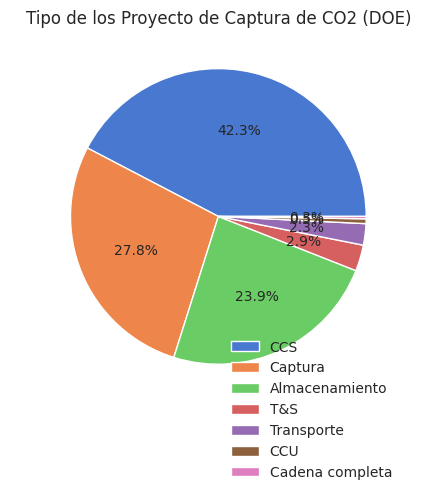

In [ ]:
#Tipos de proyectos
df_Tipo_doe= pd.DataFrame(proyectos_doe.value_counts(subset="Tipo de Proyecto", normalize=True, dropna=False))

df_Tipo_doe= df_Tipo_doe.rmul(other=100)

df_Tipo_doe.plot(kind="pie", y="proportion", legend=True, ylabel=" ",autopct='%1.1f%%'
  , textprops={'size': 'smaller'}, radius=1,labeldistance=None, title="Tipo de los Proyecto de Captura de CO2 (DOE)")

plt.legend(loc='best', bbox_to_anchor=(0.5,0.2), ncols=1, framealpha=0,fontsize="small")


plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_1/1_perc_tipo_does.png")
plt.show()

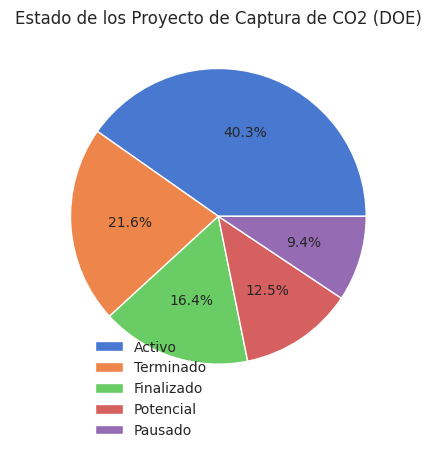

In [ ]:
##Estado
df_estado_doe= pd.DataFrame(proyectos_doe.value_counts(subset="Estado del Proyecto", normalize=True, dropna=False))
perc_estado_doe= df_estado_doe.rmul(other=100)

perc_estado_doe.plot(kind="pie", y="proportion", legend=True, ylabel=" ",autopct='%1.1f%%'
  , textprops={'size': 'smaller'}, radius=1,labeldistance=None, title="Estado de los Proyecto de Captura de CO2 (DOE)")

plt.legend(loc ='best', bbox_to_anchor=(0.5,0.2), ncols=1, framealpha=0,fontsize="small")
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_1/2_perc_estado_doe.png")
plt.show()

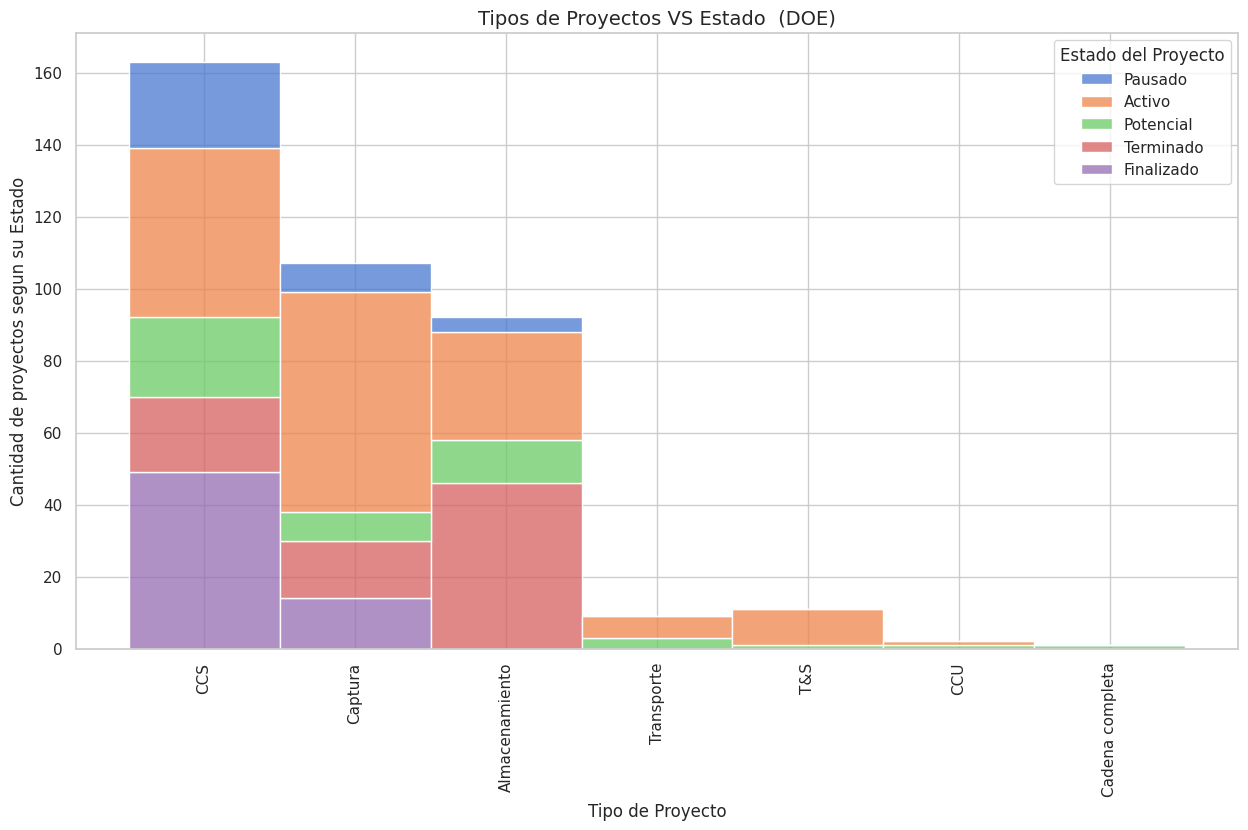

In [ ]:
n=proyectos_doe["Tipo de Proyecto"].unique().tolist()
ind=np.arange(len(n))
plt.figure(figsize=(15,8))

sns.histplot(proyectos_doe, x="Tipo de Proyecto", hue="Estado del Proyecto", stat="count", multiple="stack", binwidth=1.5, legend=True)

plt.xticks(ind, n, rotation=90)
plt.xlabel("Tipo de Proyecto")
plt.ylabel("Cantidad de proyectos segun su Estado")
plt.title("Tipos de Proyectos VS Estado  (DOE)", fontsize=14)

plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_1/3_Tipo_Estado_doe.png")
plt.show()


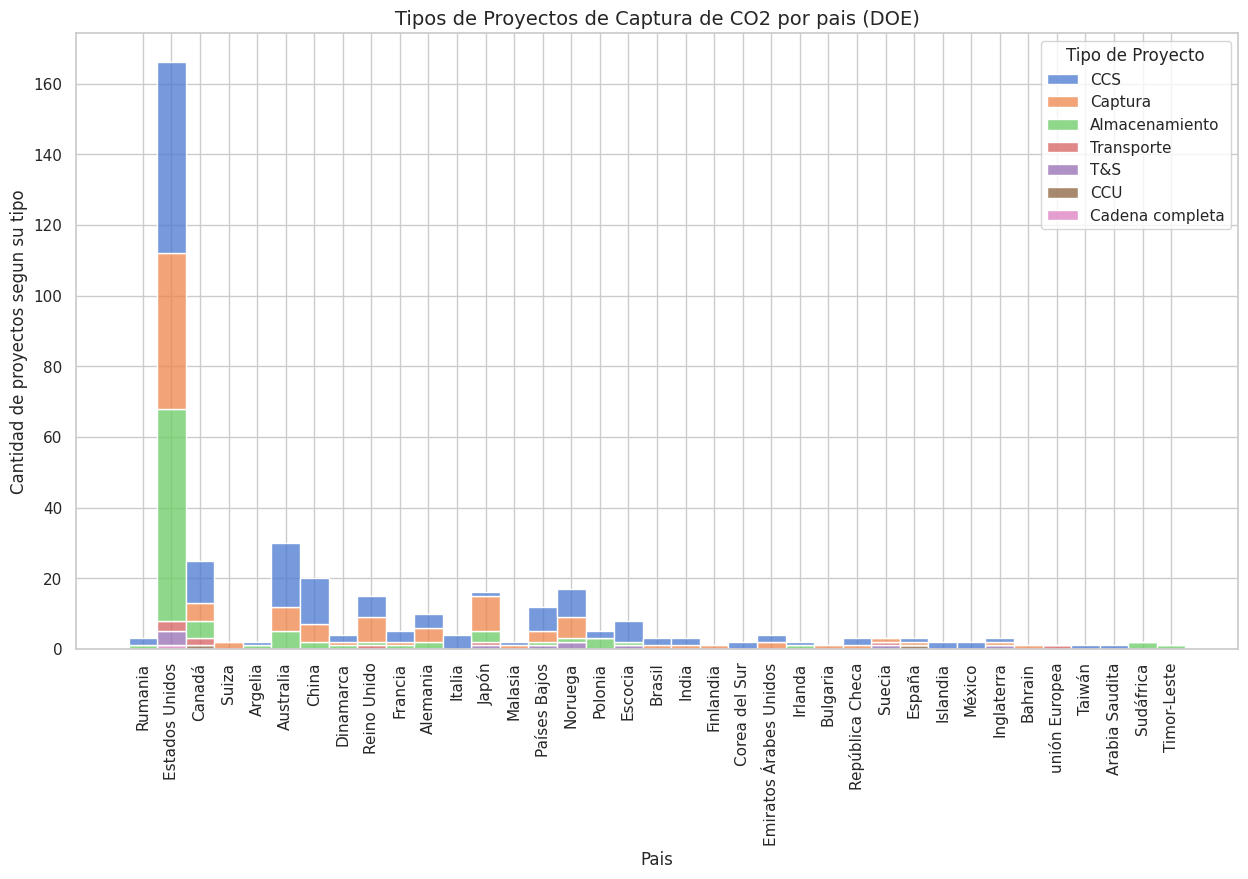

In [ ]:
n=proyectos_doe["Pais"].unique().tolist()
ind=np.arange(len(n))
plt.figure(figsize=(15,8))

sns.histplot(proyectos_doe, x="Pais", hue="Tipo de Proyecto", stat="count", multiple="stack", binwidth=1.5, legend=True)

plt.xticks(ind, n, rotation=90)
plt.xlabel("Pais")
plt.ylabel("Cantidad de proyectos segun su tipo")
plt.title("Tipos de Proyectos de Captura de CO2 por pais (DOE)", fontsize=14)

plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_1/4_Tipo_Pais_doe.png")
plt.show()


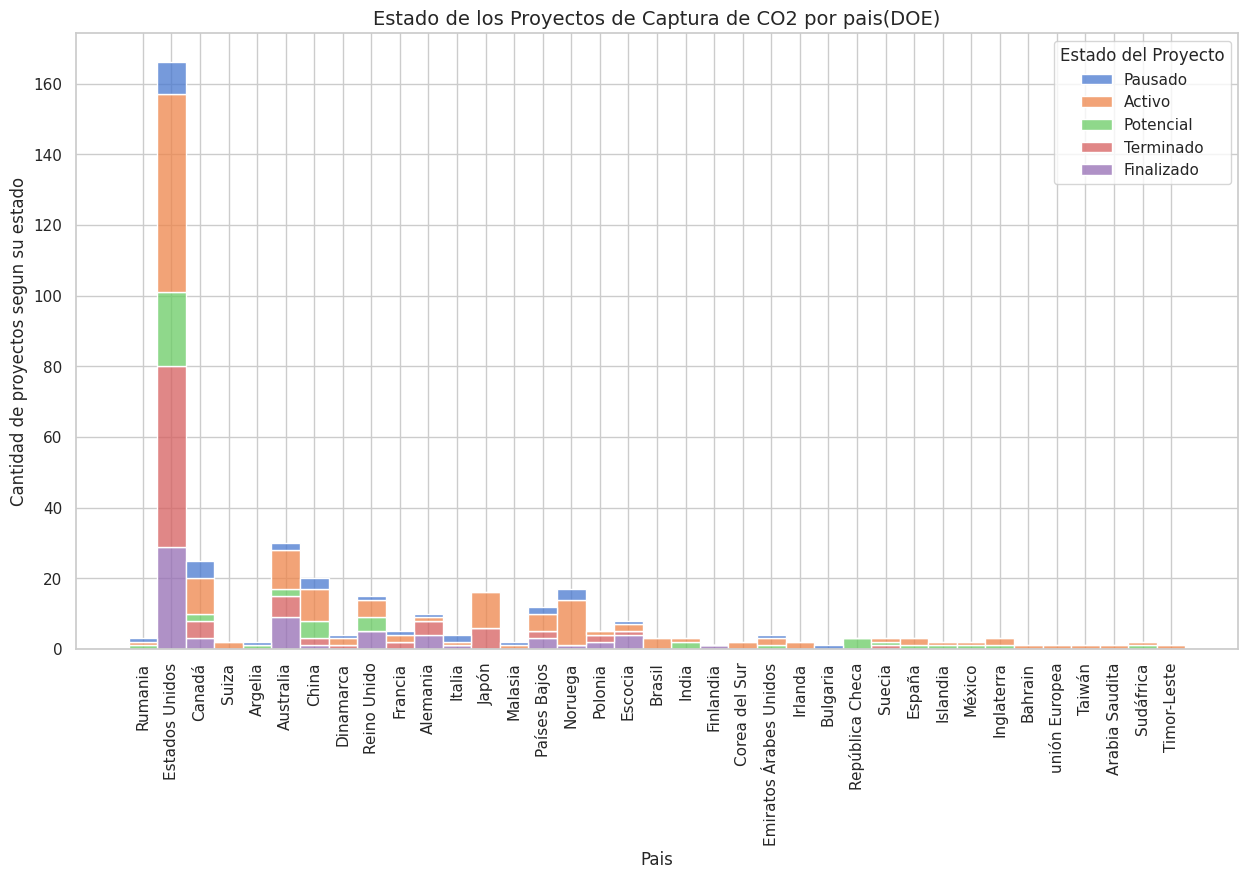

In [ ]:
p=proyectos_doe["Pais"].unique().tolist()
i=np.arange(len(n))
plt.figure(figsize=(15,8))
sns.histplot(proyectos_doe, x="Pais"
  , hue="Estado del Proyecto", stat="count"
  , multiple="stack", binwidth=1.5, legend=True)
plt.xticks(ind, n, rotation=90)
plt.xlabel("Pais")
plt.ylabel("Cantidad de proyectos segun su estado")
plt.title("Estado de los Proyectos de Captura de CO2 por pais(DOE)", fontsize=14)

plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_1/5_Estados_Pais_doe.png")
plt.show()

DESCRIPTIVOS DATA SET 2

In [10]:
proyectos_iea.describe()

,Announcement,FID,Operation,Suspension/decommissioning,Project phase,Announced capacity (Mt CO2/yr),Estimated capacity by IEA (Mt CO2/yr)
count,824,255,553,6,180.000000,614.000000,645.000000
mean,2020-10-27 23:21:33.203883776,2022-11-06 03:34:35.294117632,2026-03-05 22:47:05.316455680,2017-09-01 04:00:00,1.605556,3.389782,3.449963
min,1982-01-01 00:00:00,1984-01-01 00:00:00,1972-01-01 00:00:00,2004-01-01 00:00:00,1.000000,0.000000,0.001000
25%,2021-01-01 00:00:00,2023-01-01 00:00:00,2025-01-01 00:00:00,2012-07-02 00:00:00,1.000000,0.400000,0.400000
50%,2022-01-01 00:00:00,2024-01-01 00:00:00,2027-01-01 00:00:00,2020-01-01 12:00:00,1.000000,1.200000,1.300000
75%,2023-01-01 00:00:00,2024-01-01 00:00:00,2029-01-01 00:00:00,2024-07-02 06:00:00,2.000000,3.000000,3.000000
max,2024-01-01 00:00:00,2029-01-01 00:00:00,2040-01-01 00:00:00,2026-01-01 00:00:00,4.000000,250.000000,250.000000
std,NaN,NaN,NaN,NaN,0.705107,11.885486,11.767173


In [11]:
proyectos_iea.reset_index(drop=True, inplace=True)
skim(proyectos_iea)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 844    │ │ string      │ 11    │                                                          │
│ │ Number of columns │ 18     │ │ datetime64  │ 4     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 3     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━┳━━━━━┳━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column               ┃ NA  ┃ NA %               ┃ mean  ┃ sd     ┃ p0    ┃ p25 ┃ p50 ┃ p75 ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━╇━━━━━╇━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │ Project phase        │ 664 │  78.67298578199052 │ 1.606 │ 0.7051 │     1 │   1 │   1 │   2 │    4 │ █ ▆ ▁  │  │
│ │ Announced capacity   │ 230 │ 27.251184834123222 │  3.39 │  11.89 │     0 │ 0.4 │ 1.2 │   3 │  250 │   █    │  │
│ │ (Mt CO2/yr)          │     │                    │       │        │       │     │     │     │      │        │  │
│ │ Estimated capacity   │ 199 │ 23.578199052132703 │  3.45 │  11.77 │ 0.001 │ 0.4 │ 1.3 │   3 │  250 │   █    │  │
│ │ by IEA (Mt CO2/yr)   │     │                    │       │        │       │     │     │     │      │        │  │
│ └──────────────────────┴─────┴────────────────────┴───────┴────────┴───────┴─────┴─────┴─────┴──────┴────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓  │
│ ┃ column                     ┃ NA    ┃ NA %                    ┃ first         ┃ last          ┃ frequency   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩  │
│ │ Announcement               │    20 │      2.3696682464454977 │  1982-01-01   │  2024-01-01   │ None        │  │
│ │ FID                        │   589 │        69.7867298578199 │  1984-01-01   │  2029-01-01   │ None        │  │
│ │ Operation                  │   291 │       34.47867298578199 │  1972-01-01   │  2040-01-01   │ None        │  │
│ │ Suspension/decommissioning │   838 │       99.28909952606635 │  2004-01-01   │  2026-01-01   │ None        │  │
│ └────────────────────────────┴───────┴─────────────────────────┴───────────────┴───────────────┴─────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ Project   │  0 │    0 │ H2BE      │ CCUS hub  │ 3D DMX    │ e-Alto    │        35 │       5.3 │       4443 │  │
│ │ name      │    │      │           │ at        │ Arce

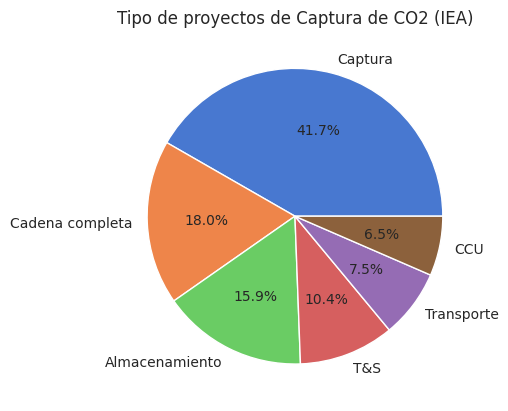

In [ ]:
df_tipo_iea= pd.DataFrame(proyectos_iea.value_counts(subset="Tipo de Proyecto", normalize=True, dropna=False))
perc_tipo_iea= df_tipo_iea.rmul(other=100)
perc_tipo_iea.plot(kind="pie", y="proportion", legend=False, ylabel=" ", title="Tipo de proyectos de Captura de CO2 (IEA)", autopct='%1.1f%%', textprops={'size': 'smaller'}, radius=1 )
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/img2.png")


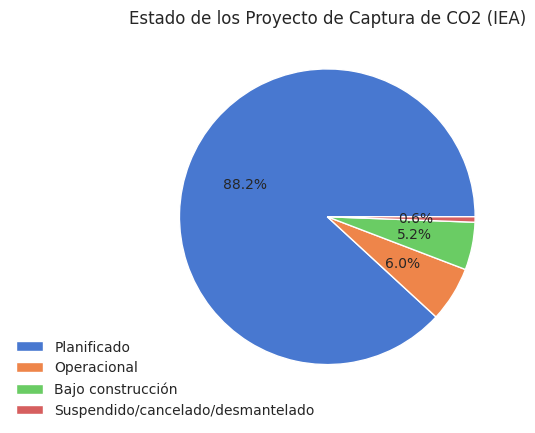

In [12]:
df_estado_iea= pd.DataFrame(proyectos_iea.value_counts(subset="Estado del Proyecto", normalize=True, dropna=False))
perc_estado_iea= df_estado_iea.rmul(other=100)
perc_estado_iea.plot(kind="pie", y="proportion", legend=True, ylabel=" ",autopct='%1.1f%%', textprops={'size': 'smaller'}, radius=1,labeldistance=None, title="Estado de los Proyecto de Captura de CO2 (IEA)")
plt.legend(loc='best', bbox_to_anchor=(0.5,0.2), ncols=1, framealpha=0,fontsize="small")
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/img1.png")

Analisis descriptivo

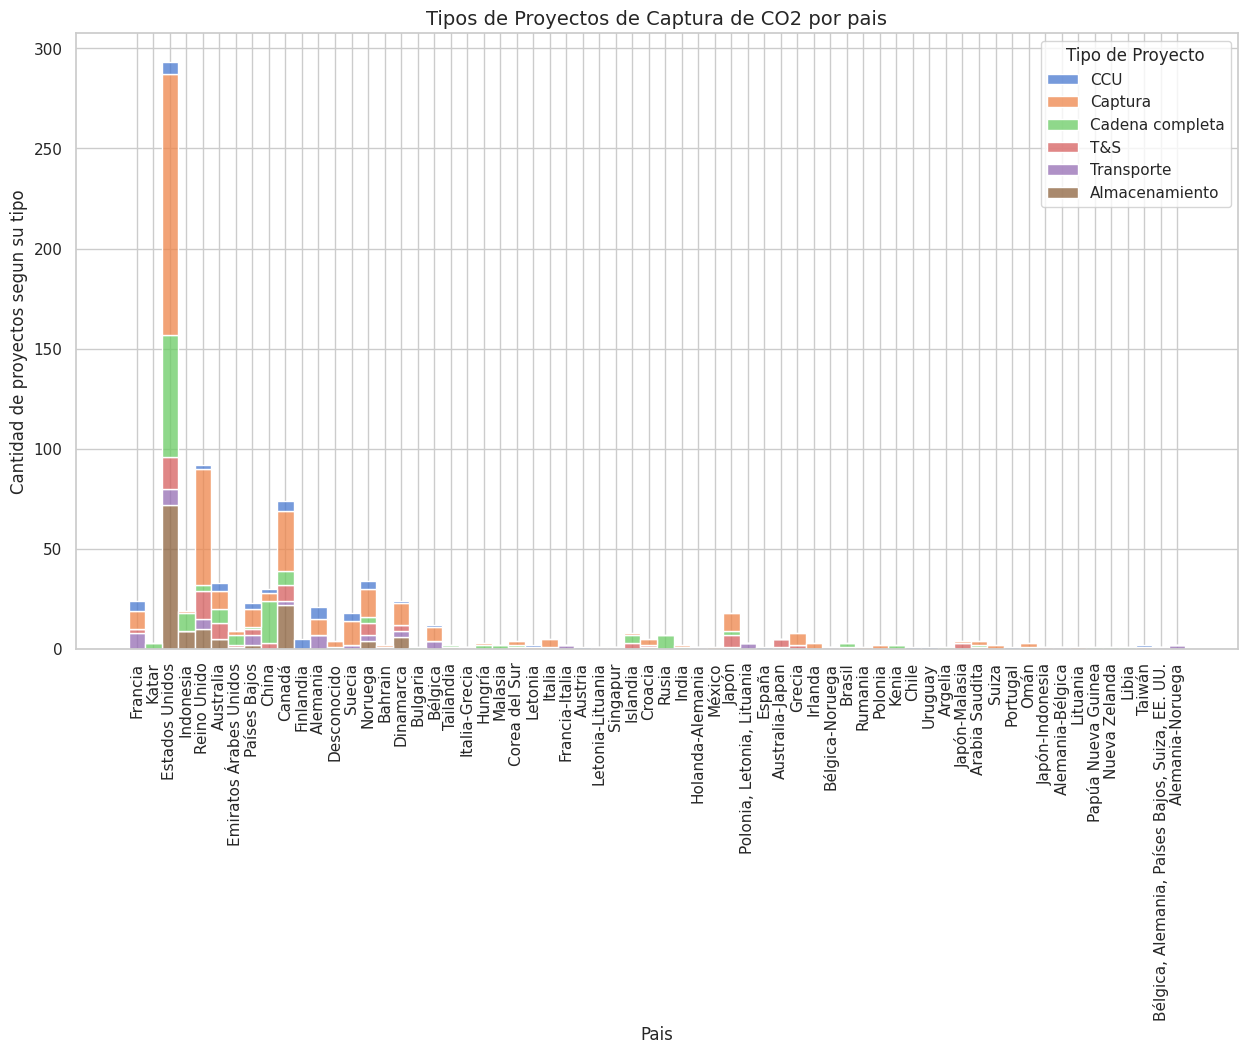

<Figure size 640x480 with 0 Axes>

In [ ]:
n=proyectos_iea["Pais"].unique().tolist()
ind=np.arange(len(n))
plt.figure(figsize=(15,8))
sns.histplot(proyectos_iea, x="Pais", hue="Tipo de Proyecto", stat="count", multiple="stack", binwidth=1.5, legend=True)
plt.xticks(ind, n, rotation=90)
plt.xlabel("Pais")
plt.ylabel("Cantidad de proyectos segun su tipo")
plt.title("Tipos de Proyectos de Captura de CO2 por pais", fontsize=14)
plt.show()
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/Tipo_Dataset2.png")

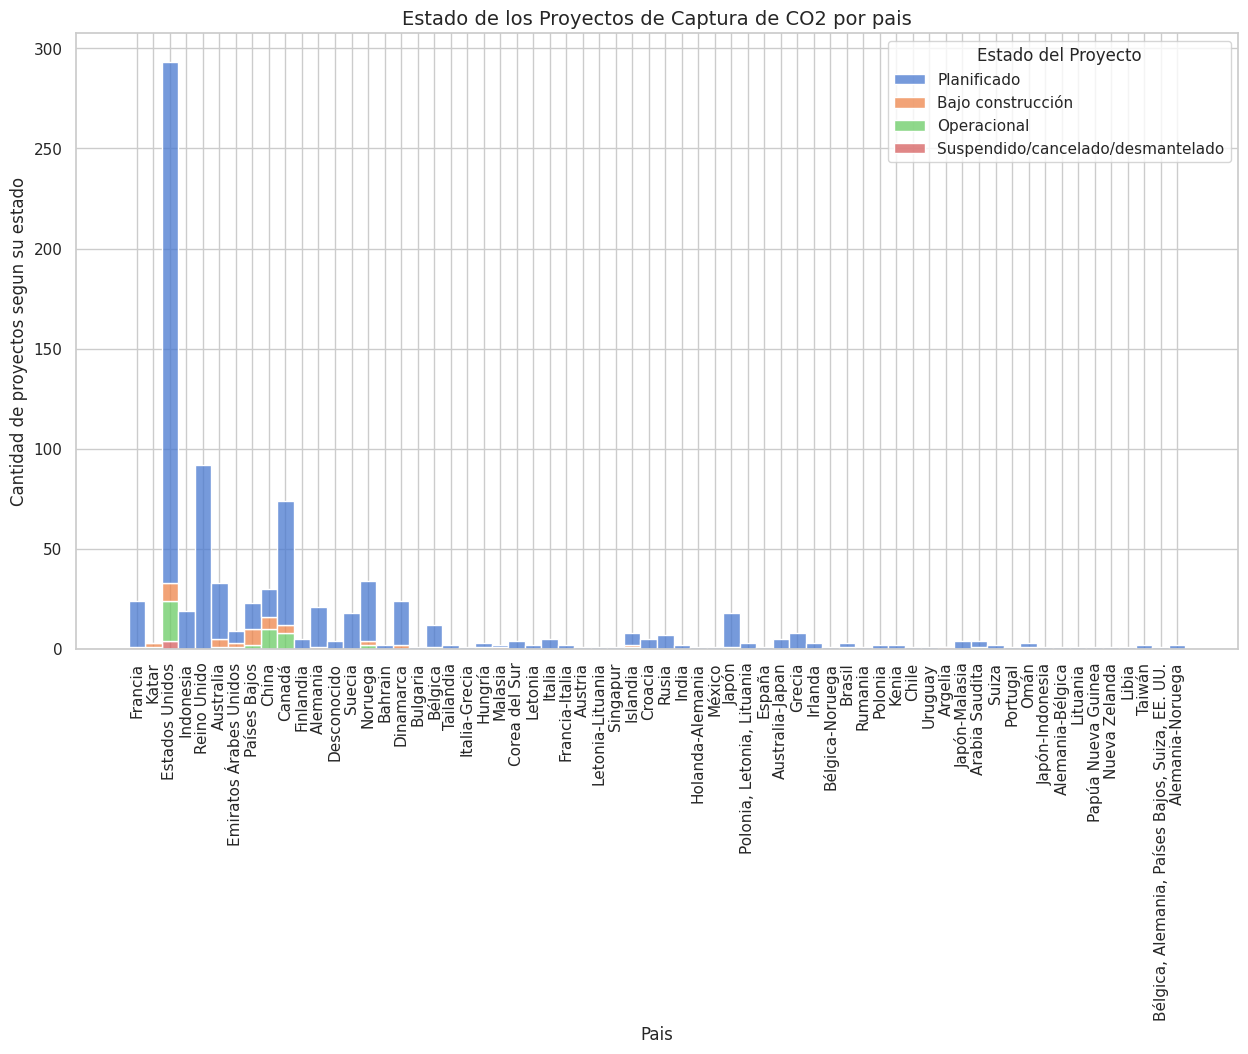

<Figure size 640x480 with 0 Axes>

In [ ]:
p=proyectos_iea["Pais"].unique().tolist()
i=np.arange(len(n))
plt.figure(figsize=(15,8))
sns.histplot(proyectos_iea, x="Pais", hue="Estado del Proyecto", stat="count", multiple="stack", binwidth=1.5, legend=True)
plt.xticks(ind, n, rotation=90)
plt.xlabel("Pais")
plt.ylabel("Cantidad de proyectos segun su estado")
plt.title("Estado de los Proyectos de Captura de CO2 por pais", fontsize=14)
plt.show()
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/Estados_DS2.png")

In [ ]:
estado=proyectos_iea.groupby(["Pais", "Estado del Proyecto"]).size().reset_index()
tipo=proyectos_iea.groupby(["Pais","Tipo de Proyecto"]).size().reset_index()

,Pais,Tipo de Proyecto,0
0,Alemania,CCU,6
1,Alemania,Captura,8
2,Alemania,Transporte,7
3,Alemania-Bélgica,Transporte,1
4,Alemania-Noruega,Transporte,2
...,...,...,...
133,Tailandia,Almacenamiento,1
134,Tailandia,Cadena completa,1
135,Taiwán,CCU,1
136,Taiwán,Captura,1


In [13]:
#Contamos la cantidad de proyectos por pais
p=proyectos_iea.groupby("Pais").size().reset_index()
p.rename({0:"conteo"}, axis="columns", inplace=True)
t=proyectos_iea.groupby(["Estado del Proyecto","Tipo de Proyecto"]).size()
df_desc=proyectos_iea.groupby(["Pais","Estado del Proyecto","Tipo de Proyecto"]).size().reset_index()


Text(0, 0.5, 'N° de Proyectos')

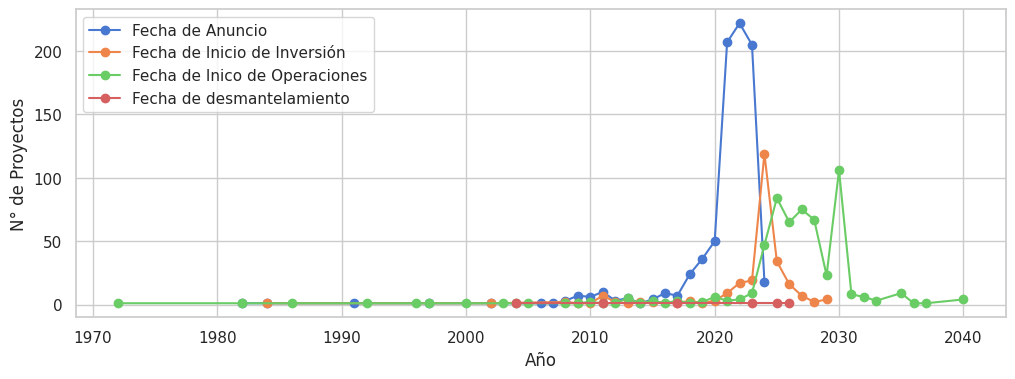

In [14]:
##Series de tiempo
fig, axs = plt.subplots(figsize=(12, 4))
proyectos_iea.groupby(proyectos_iea["Announcement"].dt.year).size().plot(
    style="-o", rot=0, ax=axs, label="Fecha de Anuncio")
proyectos_iea.groupby(proyectos_iea["FID"].dt.year).size().plot(
    style="-o", rot=0, ax=axs, label="Fecha de Inicio de Inversión")
proyectos_iea.groupby(proyectos_iea["Operation"].dt.year).size().plot(
    style="-o", rot=0, ax=axs, label="Fecha de Inico de Operaciones")
proyectos_iea.groupby(proyectos_iea["Suspension/decommissioning"].dt.year).size().plot(
    style="-o", rot=0, ax=axs, label="Fecha de desmantelamiento")
plt.legend()
plt.xlabel("Año")
plt.ylabel("N° de Proyectos")


Text(0, 0.5, 'N° de Proyectos')

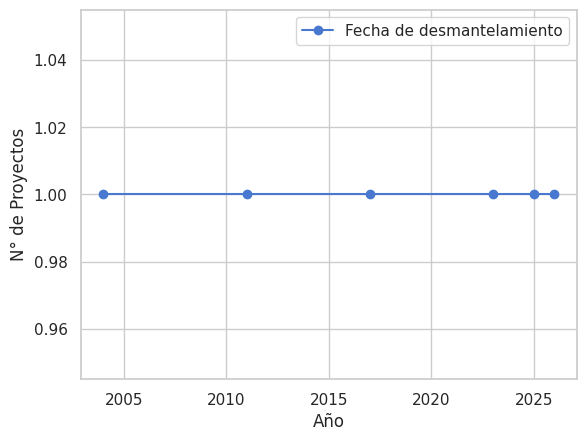

In [15]:
##Hacemos un "zoom" a la fecha de desmantelamiento de los proyectos para tener una mejor visualización
proyectos_iea.groupby(proyectos_iea["Suspension/decommissioning"].dt.year).size().plot(
    style="-o", rot=0, label="Fecha de desmantelamiento")
plt.legend()
plt.xlabel("Año")
plt.ylabel("N° de Proyectos")

In [16]:
#Filtramos paises segun el numero de proyecctos para poder visualizar mejor los histogramas
f= p.loc[p["conteo"] >= 30, "Pais"].tolist() #Extraemos los paises con 30 o mas proyectos
g= p.loc[p["conteo"] < 30, "Pais"].tolist() #Extraemos los paises con menos 30 proyectos
df_f=proyectos_iea[proyectos_iea['Pais'].isin(f)] #df_f contiene solo las filas con los paises que están en f
df_g=proyectos_iea[proyectos_iea['Pais'].isin(g)] #df_g contiene solo las filas con los paises que están en g

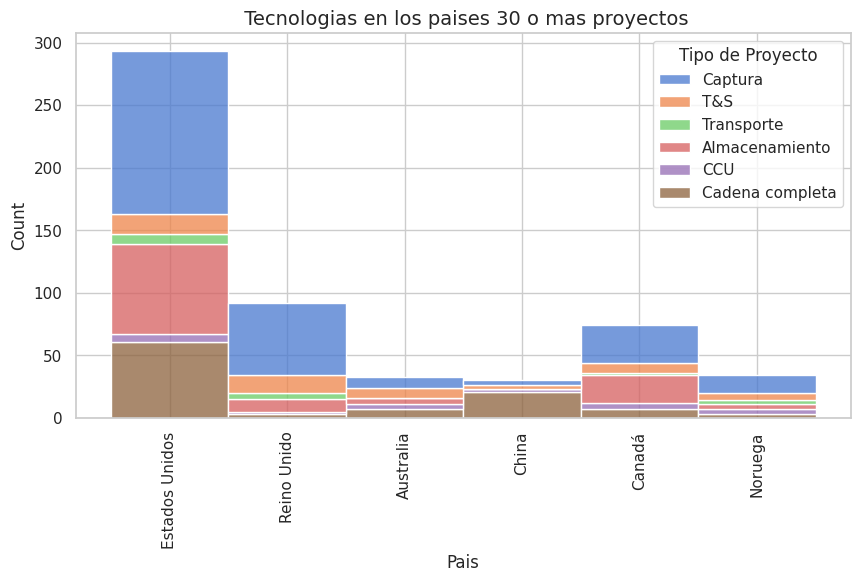

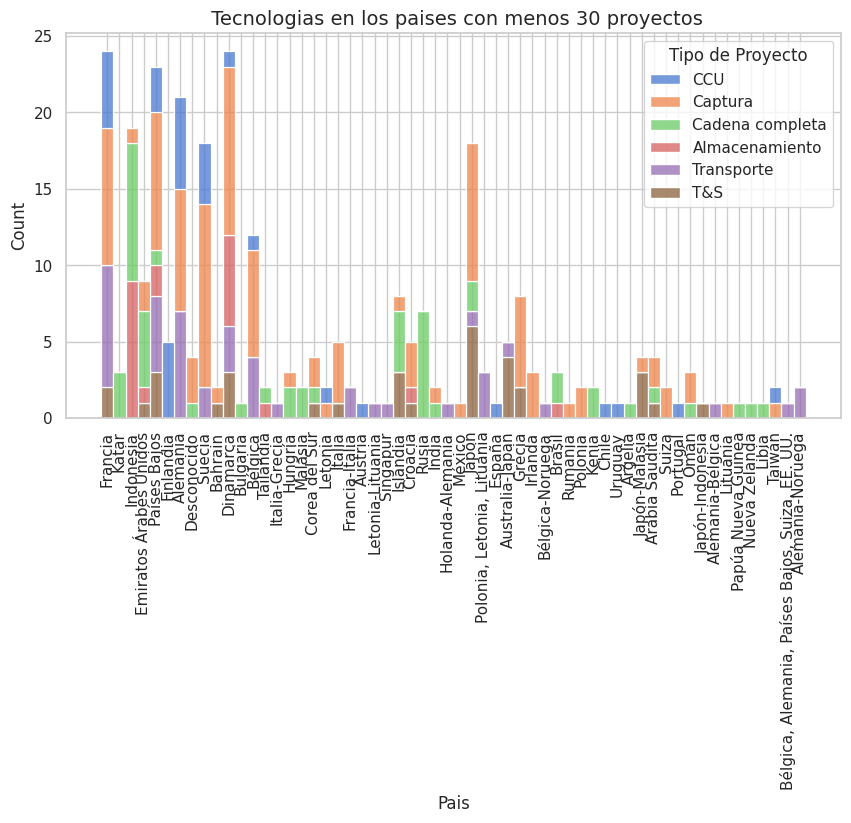

In [17]:
pf=df_f["Pais"].unique().tolist()
i=np.arange(len(pf))
pg=df_g["Pais"].unique().tolist()
j=np.arange(len(pg))
#Graficamos
plt.figure(figsize=(10,5))
sns.histplot(df_f, x="Pais", hue="Tipo de Proyecto", stat="count", multiple="stack", binwidth=1.5, legend=True)
plt.xticks(i, pf, rotation=90)
plt.title(" Tecnologias en los paises 30 o mas proyectos", fontsize=14)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/Tipo_DS2_1.png")
plt.figure(figsize=(10,5))
sns.histplot(df_g, x="Pais", hue="Tipo de Proyecto", stat="count", multiple="stack", binwidth=1.5, legend=True)
plt.xticks(j, pg, rotation=90)
plt.title(" Tecnologias en los paises con menos 30 proyectos", fontsize=14)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/Tipo_DS2_2.png")


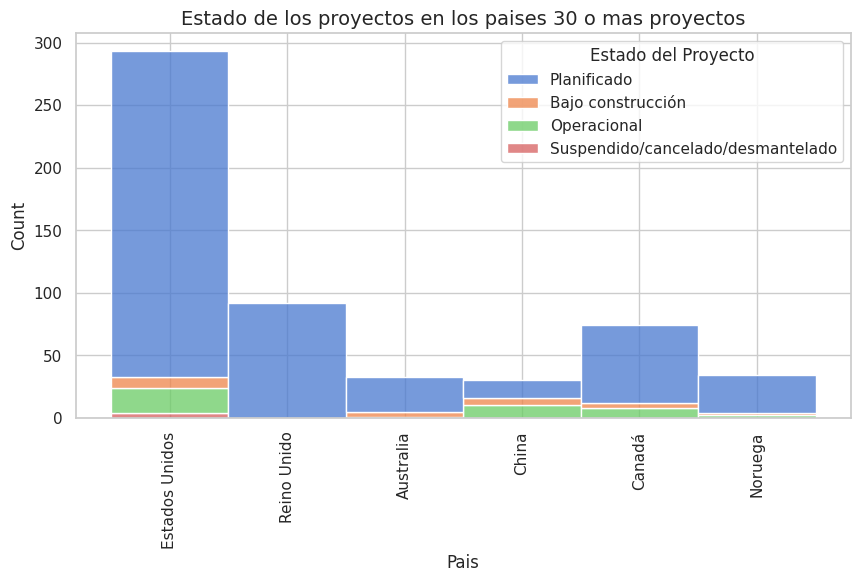

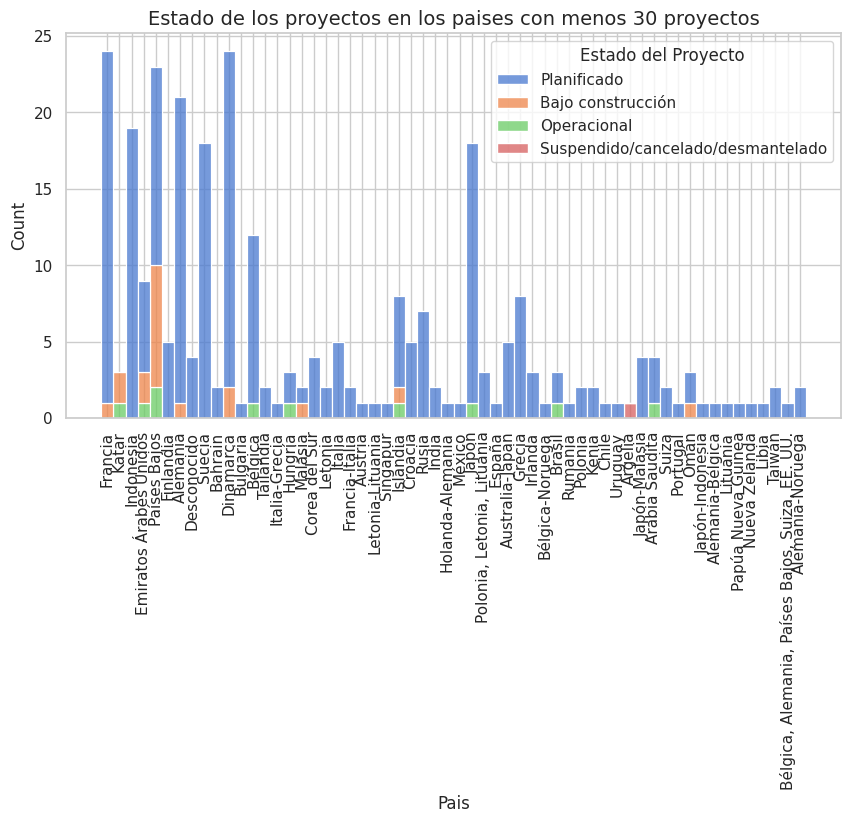

In [18]:
pf=df_f["Pais"].unique().tolist()
i=np.arange(len(pf))
pg=df_g["Pais"].unique().tolist()
j=np.arange(len(pg))
#Graficamos
plt.figure(figsize=(10,5))
sns.histplot(df_f, x="Pais", hue="Estado del Proyecto", stat="count", multiple="stack", binwidth=1.5, legend=True)
plt.xticks(i, pf, rotation=90)
plt.title("Estado de los proyectos en los paises 30 o mas proyectos", fontsize=14)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/Estado_DS2_1.png")
plt.figure(figsize=(10,5))
sns.histplot(df_g, x="Pais", hue="Estado del Proyecto", stat="count", multiple="stack", binwidth=1.5, legend=True)
plt.xticks(j, pg, rotation=90)
plt.title("Estado de los proyectos en los paises con menos 30 proyectos", fontsize=14)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/Estado_DS2_2.png")

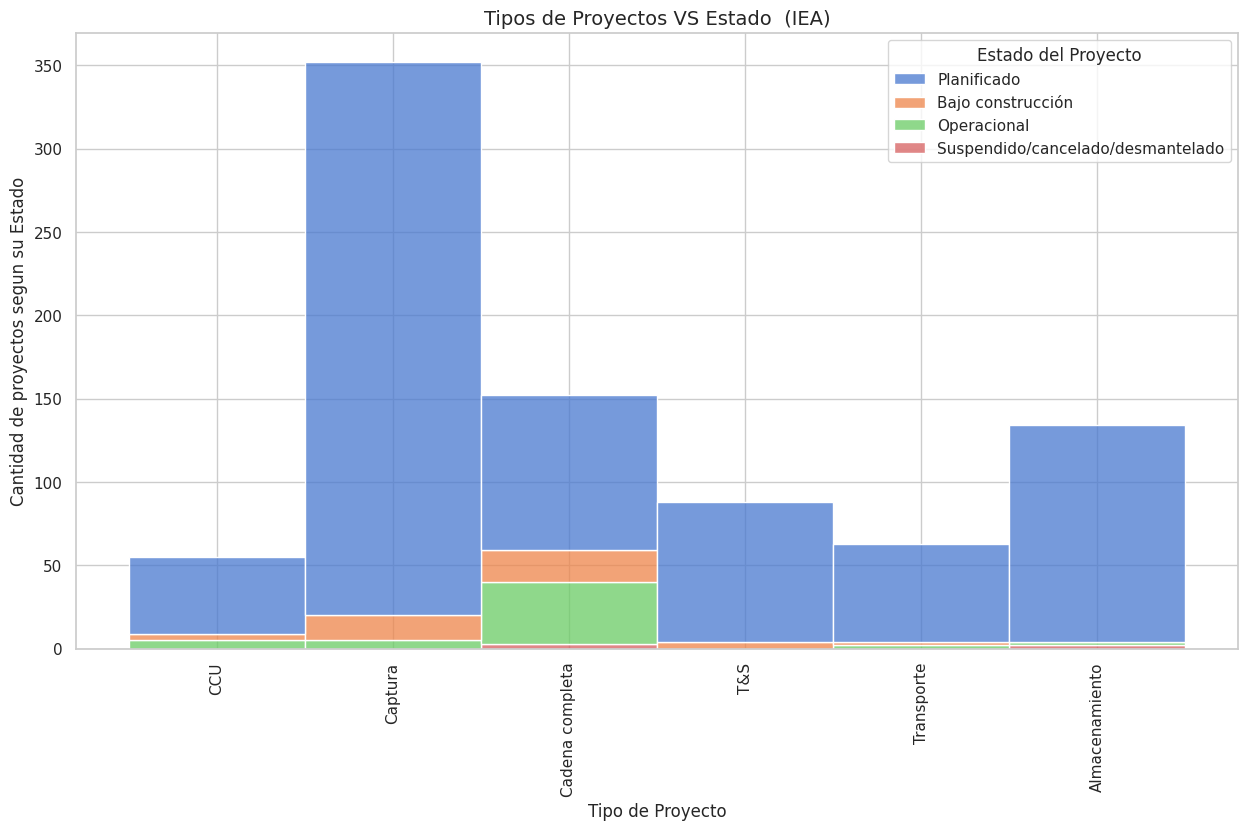

In [19]:
n=proyectos_iea["Tipo de Proyecto"].unique().tolist()
ind=np.arange(len(n))
plt.figure(figsize=(15,8))
sns.histplot(proyectos_iea, x="Tipo de Proyecto", hue="Estado del Proyecto", stat="count", multiple="stack", binwidth=1.5, legend=True)
plt.xticks(ind, n, rotation=90)
plt.xlabel("Tipo de Proyecto")
plt.ylabel("Cantidad de proyectos segun su Estado")
plt.title("Tipos de Proyectos VS Estado  (IEA)", fontsize=14)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/Tipo_DS2_3.png")

Estadisticos de capacidad de Captura por Industria y Por Pais

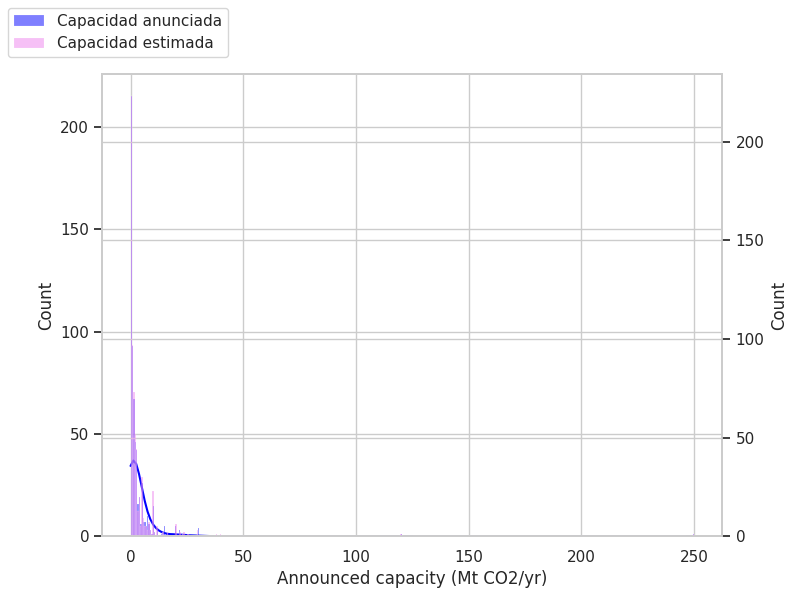

In [20]:
#histogramas para las variables numericas Capacidad Anunciada y Capacidad estimada por la IEA
fig, ax1= plt.subplots(figsize=[8,6]) #Ajustar el tamaño de la grafica
##Determinamos el tipo de grafico
sns.histplot(proyectos_iea['Announced capacity (Mt CO2/yr)'], kde=True, color="blue", label="Capacidad anunciada", ax=ax1, alpha=0.5 )
ax2=ax1.twinx()
sns.histplot(proyectos_iea['Estimated capacity by IEA (Mt CO2/yr)'], kde=False, color="violet", label="Capacidad estimada", ax=ax2, alpha=0.5)
fig.legend(loc="upper left")
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/hist_DS2.png")

In [21]:
df_sector=proyectos_iea.groupby(["Pais","Industria","Tipo de Proyecto"]).size().reset_index()
df_sector.rename({0:"conteo"}, axis="columns", inplace=True)
df_mean_AC=proyectos_iea.groupby(["Pais","Industria",])["Announced capacity (Mt CO2/yr)"].mean().reset_index()
df_mean_EC=proyectos_iea.groupby(["Pais","Industria",])["Estimated capacity by IEA (Mt CO2/yr)"].mean().reset_index()
df_std_AC=proyectos_iea.groupby(["Pais","Industria",])["Announced capacity (Mt CO2/yr)"].std().reset_index()
df_std_EC=proyectos_iea.groupby(["Pais","Industria",])["Estimated capacity by IEA (Mt CO2/yr)"].std().reset_index()
##Eliminamos nulos
df_mean_AC=df_mean_AC.dropna()
df_mean_EC=df_mean_EC.dropna()
df_std_AC=df_std_AC.dropna()
df_std_EC=df_std_EC.dropna()

<ipython-input-22-d59dd3d9df8d>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=proyectos_iea['Pais'], y=proyectos_iea['Announced capacity (Mt CO2/yr)'], palette="pastel")


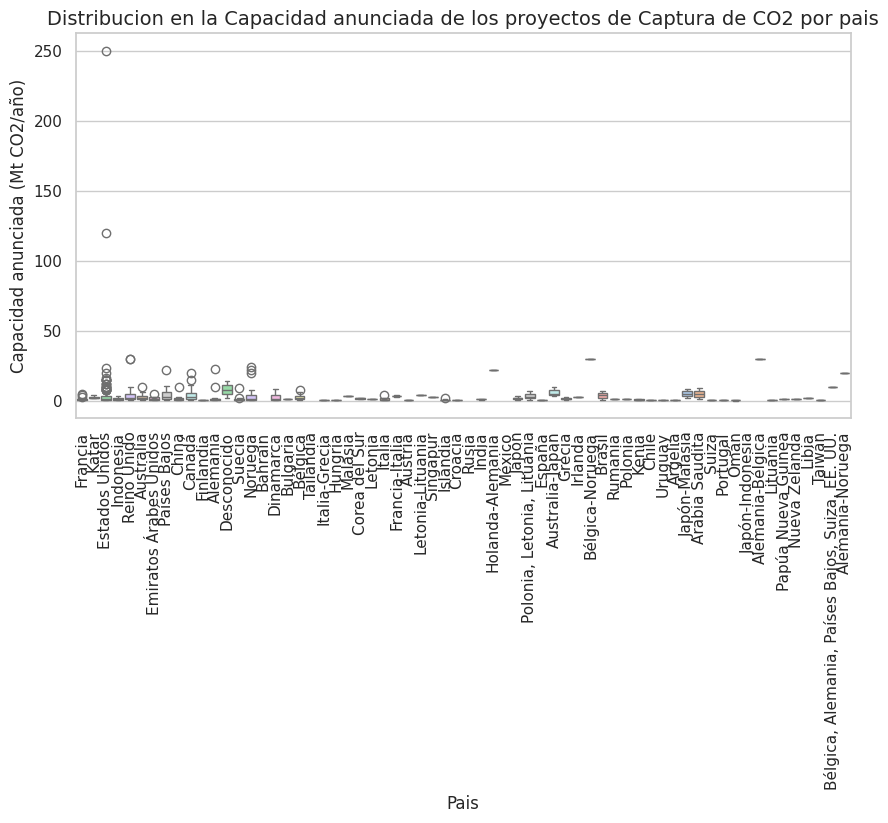

In [22]:
plt.figure(figsize=(10,5))
sns.boxplot(x=proyectos_iea['Pais'], y=proyectos_iea['Announced capacity (Mt CO2/yr)'], palette="pastel")
plt.title('Distribucion en la Capacidad anunciada de los proyectos de Captura de CO2 por pais', fontsize=14)
plt.xlabel('Pais', fontsize=12)
plt.ylabel('Capacidad anunciada (Mt CO2/año)', fontsize=12)
plt.xticks(rotation=90)
plt.gcf().set_size_inches(10,5)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/boxplot_DS2_1.png", bbox_inches='tight')


<ipython-input-23-758c9930fcf0>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=proyectos_iea['Pais'], y=proyectos_iea['Estimated capacity by IEA (Mt CO2/yr)'], palette="pastel")


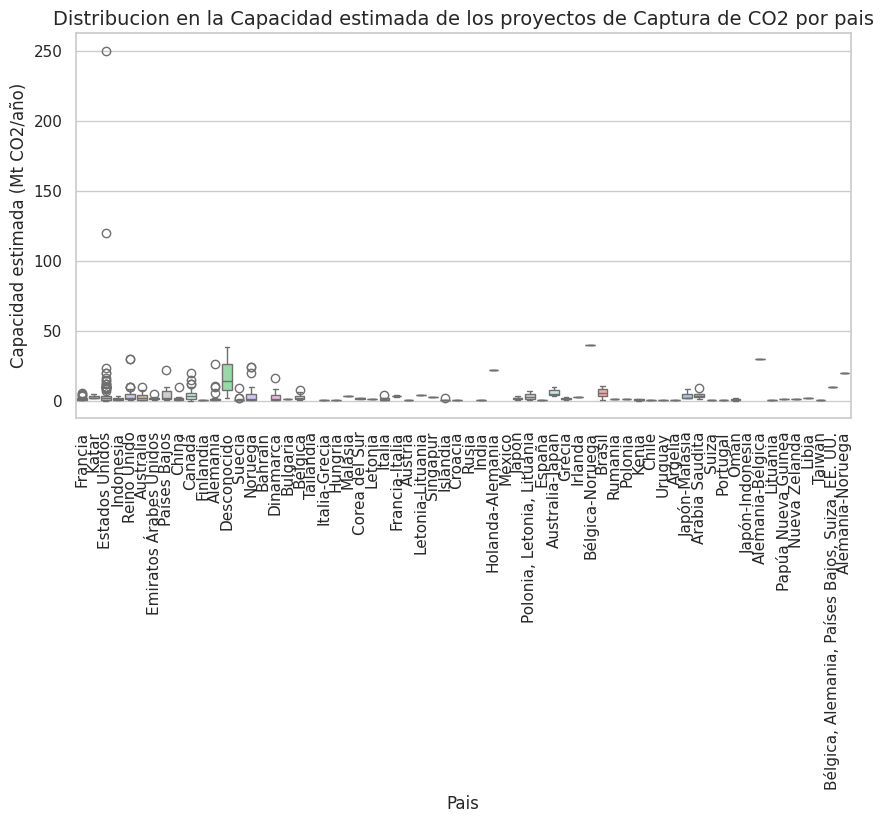

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(x=proyectos_iea['Pais'], y=proyectos_iea['Estimated capacity by IEA (Mt CO2/yr)'], palette="pastel")
plt.title('Distribucion en la Capacidad estimada de los proyectos de Captura de CO2 por pais', fontsize=14)
plt.xlabel('Pais', fontsize=12)
plt.ylabel('Capacidad estimada (Mt CO2/año)', fontsize=12)
plt.xticks(rotation=90)
plt.gcf().set_size_inches(10,5)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/boxplot_DS2_2.png", bbox_inches="tight")

<ipython-input-24-fb10c7a336de>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=proyectos_iea['Industria'], y=proyectos_iea['Announced capacity (Mt CO2/yr)'], palette="pastel")


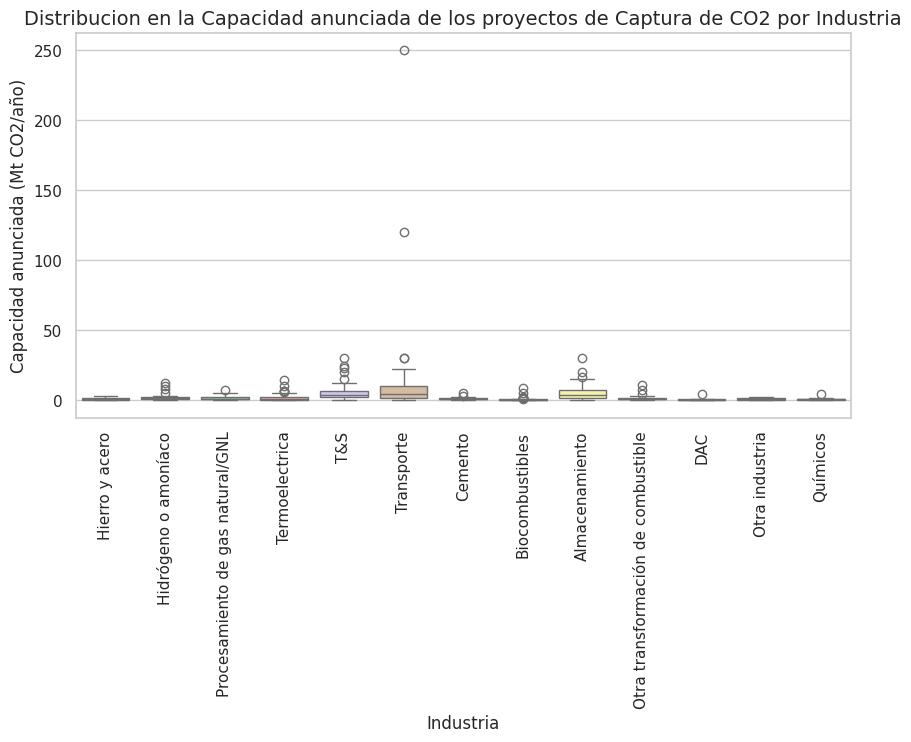

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x=proyectos_iea['Industria'], y=proyectos_iea['Announced capacity (Mt CO2/yr)'], palette="pastel")
plt.title('Distribucion en la Capacidad anunciada de los proyectos de Captura de CO2 por Industria', fontsize=14)
plt.xlabel('Industria', fontsize=12)
plt.ylabel('Capacidad anunciada (Mt CO2/año)', fontsize=12)
plt.xticks(rotation=90)
plt.gcf().set_size_inches(10,5)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/boxplot_DS2_1_2.png", bbox_inches="tight")


Comportamiento de los estadisticos por industria

<ipython-input-25-83f0a1e86f98>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=proyectos_iea['Industria'], y=proyectos_iea['Estimated capacity by IEA (Mt CO2/yr)'], palette="pastel")


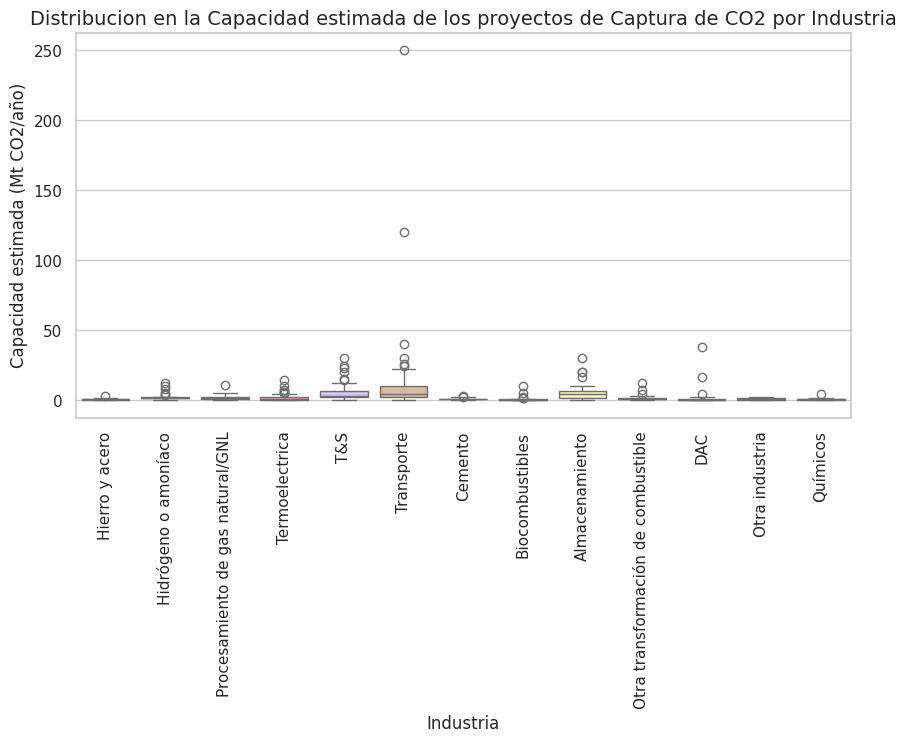

In [25]:
plt.figure(figsize=(10,5))
sns.boxplot(x=proyectos_iea['Industria'], y=proyectos_iea['Estimated capacity by IEA (Mt CO2/yr)'], palette="pastel")
plt.title('Distribucion en la Capacidad estimada de los proyectos de Captura de CO2 por Industria', fontsize=14)
plt.xlabel('Industria', fontsize=12)
plt.ylabel('Capacidad estimada (Mt CO2/año)', fontsize=12)
plt.xticks(rotation=90)
plt.gcf().set_size_inches(10,5)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/boxplot_DS2_2_2.png", bbox_inches="tight")


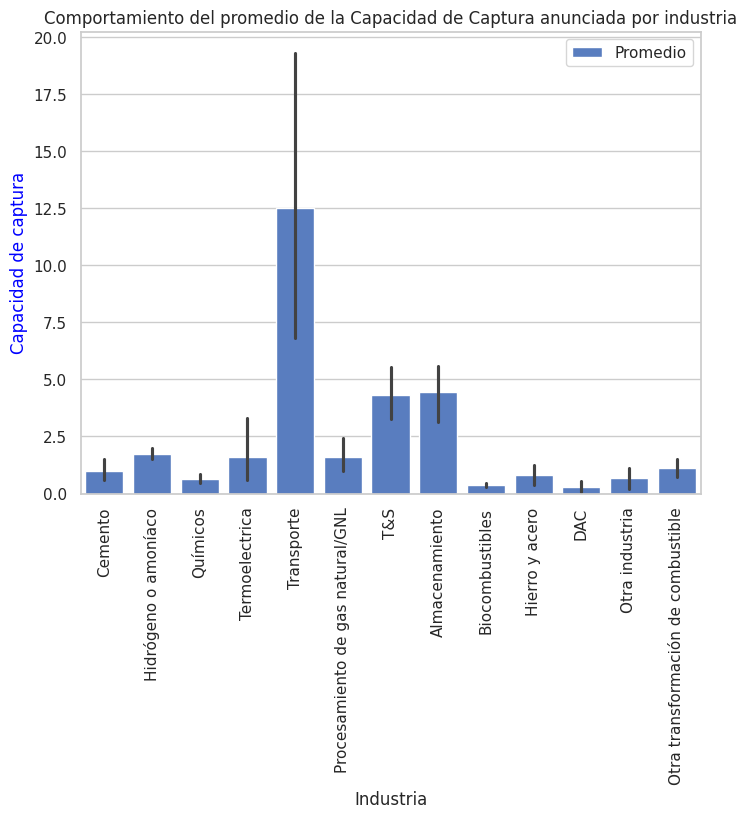

In [26]:
#Configurar el grafico
plt.plot(figsize=[8,6]) #Ajustar el tamaño de la grafica
#Grafico de barras
sns.barplot(x="Industria", y='Announced capacity (Mt CO2/yr)', data=df_mean_AC, label="Promedio")
plt.ylabel("Capacidad de captura", color="blue")
plt.xticks(rotation=90)
plt.title("Comportamiento del promedio de la Capacidad de Captura anunciada por industria")
plt.gcf().set_size_inches(8,6)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/barplot_mean_DS2_2_1.png",bbox_inches="tight")

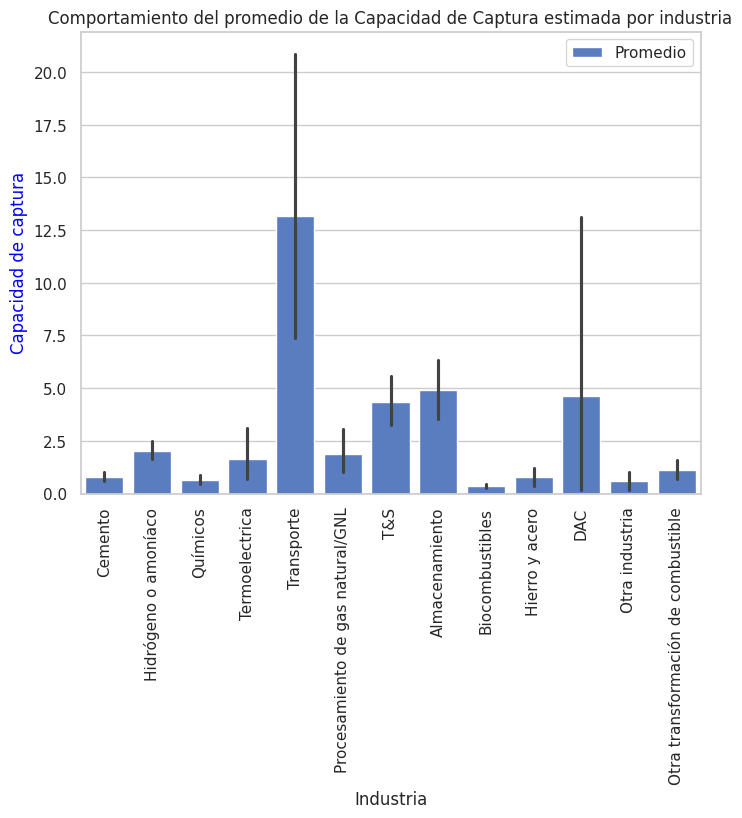

In [27]:
#Configurar el grafico
plt.plot(figsize=[8,6]) #Ajustar el tamaño de la grafica
#Grafico de barras
sns.barplot(x="Industria", y='Estimated capacity by IEA (Mt CO2/yr)', data=df_mean_EC, label="Promedio")
plt.ylabel("Capacidad de captura", color="blue")
plt.xticks(rotation=90)
plt.title("Comportamiento del promedio de la Capacidad de Captura estimada por industria")
plt.gcf().set_size_inches(8,6)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/barplot_mean_DS2_2_2.png",bbox_inches="tight")

Estadisticos de Capacidad de Captura por Pais

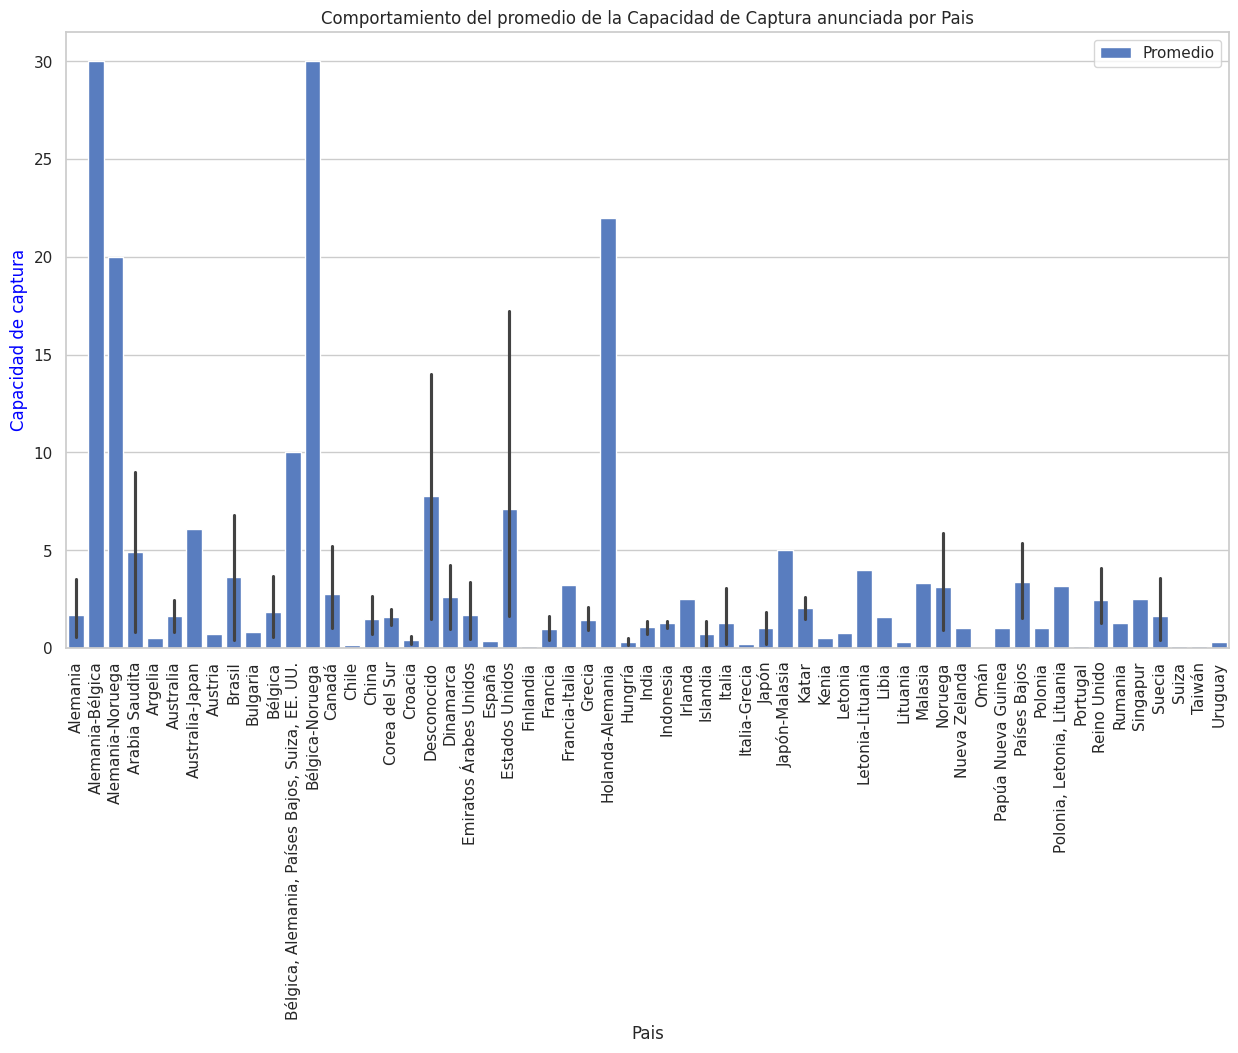

In [28]:
#Configurar el grafico
plt.plot(figsize=[15,8]) #Ajustar el tamaño de la grafica
#Grafico de barras
sns.barplot(x="Pais", y='Announced capacity (Mt CO2/yr)', data=df_mean_AC, label="Promedio")
plt.ylabel("Capacidad de captura", color="blue")
plt.xticks(rotation=90)
plt.title("Comportamiento del promedio de la Capacidad de Captura anunciada por Pais")
plt.gcf().set_size_inches(15,8)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/barplot_mean_DS2_1_1.png", bbox_inches="tight")

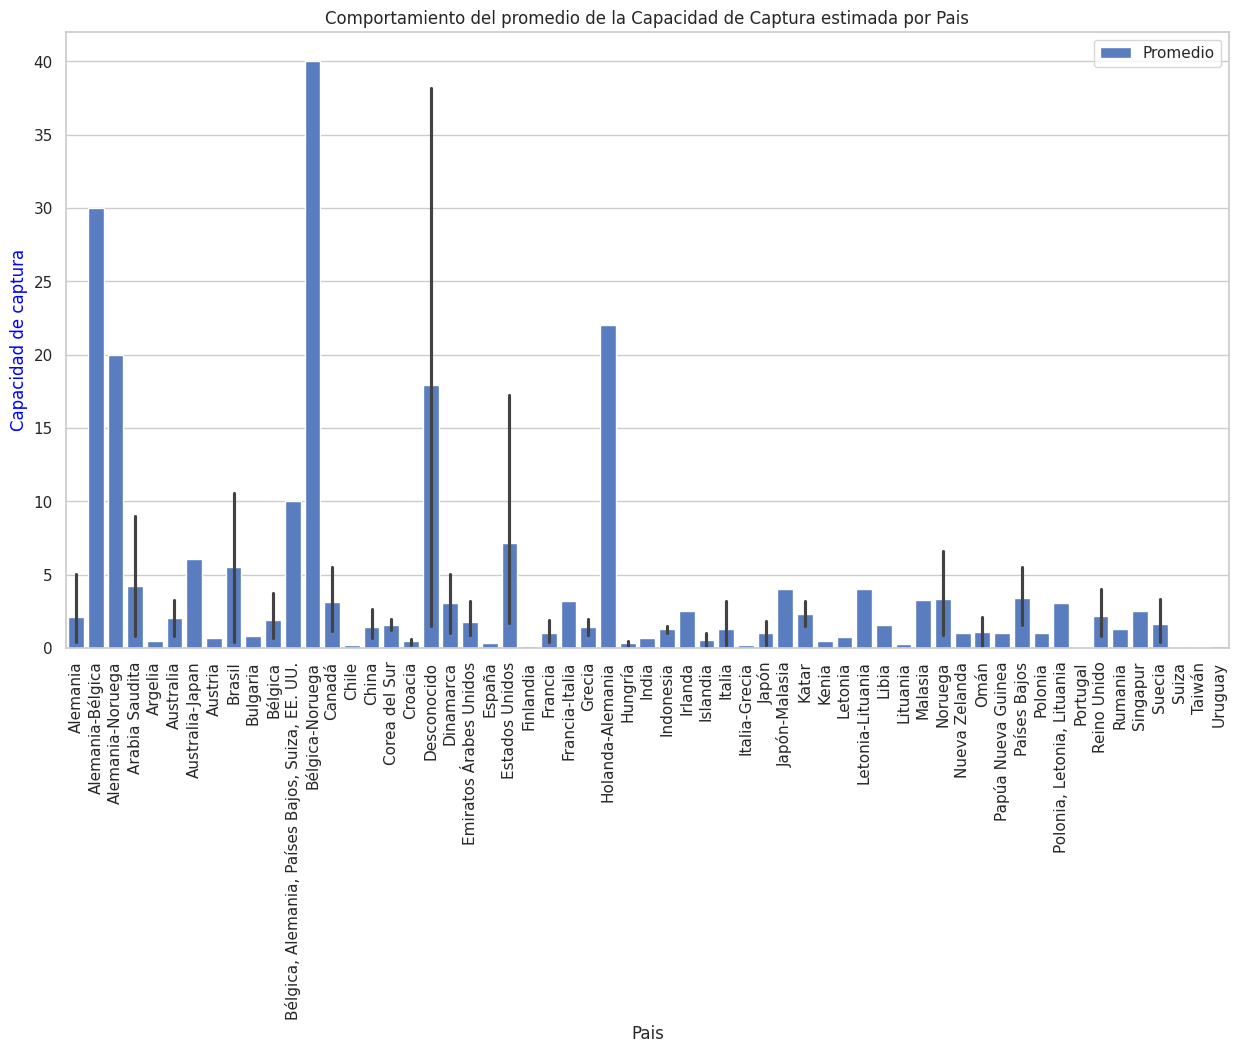

In [29]:
#Configurar el grafico
plt.plot(figsize=[15,8]) #Ajustar el tamaño de la grafica
#Grafico de barras
sns.barplot(x="Pais", y='Estimated capacity by IEA (Mt CO2/yr)', data=df_mean_EC, label="Promedio")
plt.ylabel("Capacidad de captura", color="blue")
plt.xticks(rotation=90)
plt.gcf().set_size_inches(15,8)
plt.title("Comportamiento del promedio de la Capacidad de Captura estimada por Pais")
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/barplot_mean_DS2_1_2.png", bbox_inches="tight")

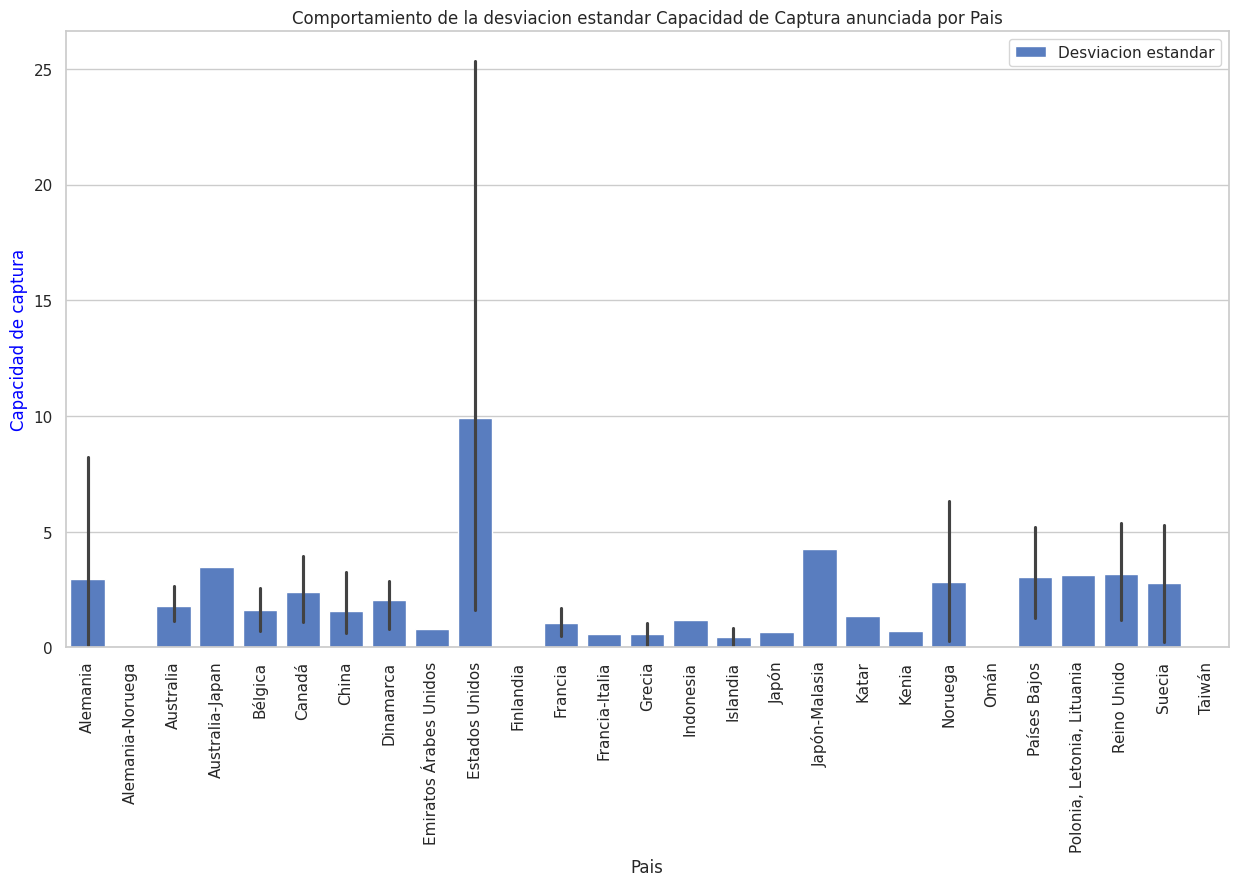

In [30]:
plt.plot(figsize=[15,8]) #Ajustar el tamaño de la grafica
sns.barplot(x="Pais", y="Announced capacity (Mt CO2/yr)", data=df_std_AC, label="Desviacion estandar")
plt.ylabel("Capacidad de captura", color="blue")
plt.xticks(rotation=90)
plt.title("Comportamiento de la desviacion estandar Capacidad de Captura anunciada por Pais")
plt.gcf().set_size_inches(15,8)
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/barplot_std_DS2_1_1.png")

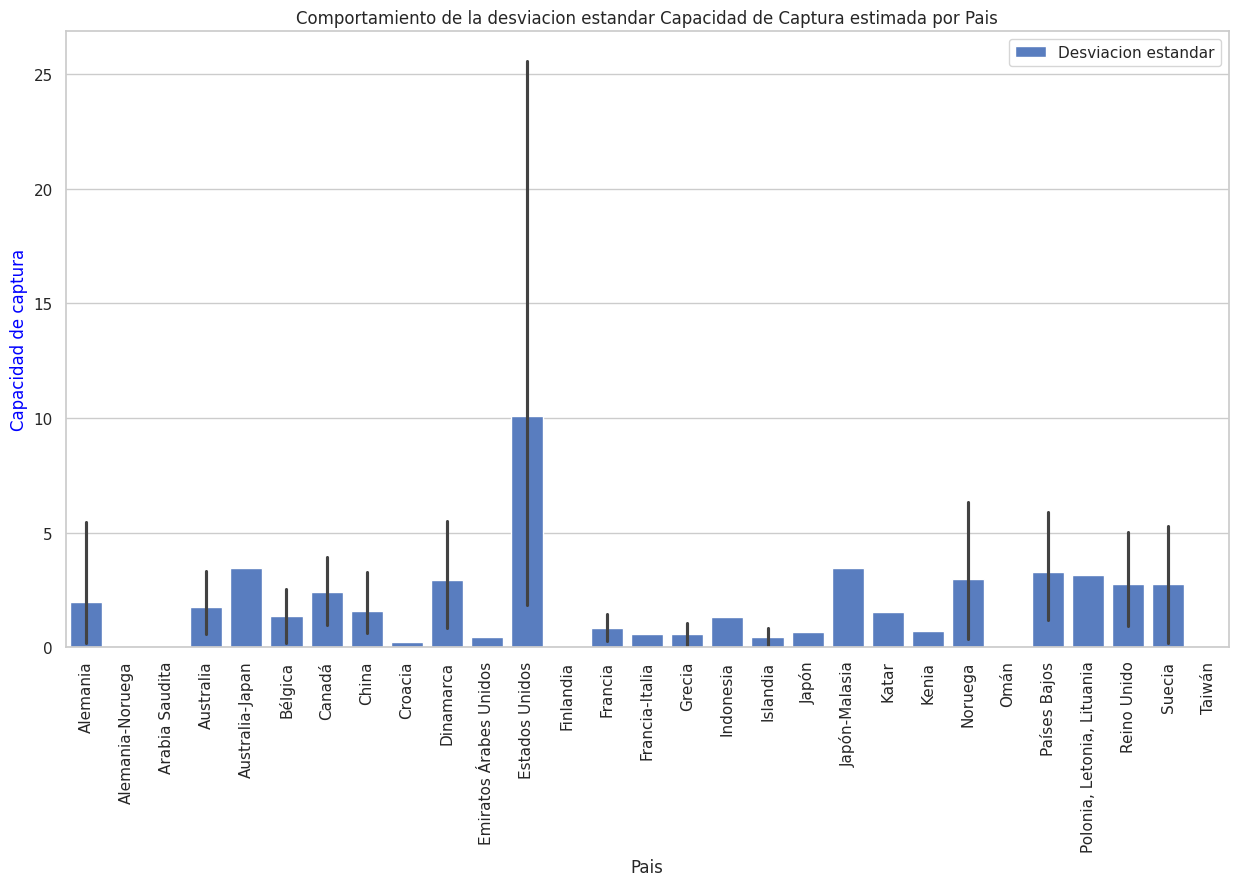

In [31]:
plt.figure(figsize=[15,8])
sns.barplot(x="Pais", y="Estimated capacity by IEA (Mt CO2/yr)", data=df_std_EC, label="Desviacion estandar")
plt.ylabel("Capacidad de captura", color="blue")
plt.xticks(rotation=90)
plt.title("Comportamiento de la desviacion estandar Capacidad de Captura estimada por Pais")
plt.savefig(fname="/content/drive/MyDrive/Energytalentotech/Dataset_2/barplot_std_DS2_1_2.png")

**Streamlit**

Diseño de Dashboard

In [ ]:
# Nota: OJO Es necesario crear una cuenta en ngrok.com para obtener un token de autenticación único.
# Esto permite exponer el servidor local a Internet.
# Una vez creada la cuenta, copia tu token desde el panel de ngrok y reemplaza el valor en la siguiente línea.

from pyngrok import ngrok
TokenNgrok="2uyEpPN3vIS13PfwtOWaEESlNyX_55HYdrA6EDAvc71umDa9n"
ngrok.set_auth_token("2uyEpPN3vIS13PfwtOWaEESlNyX_55HYdrA6EDAvc71umDa9n")


In [ ]:
# Uso de localtunnel para exponer el puerto local 8501 a Internet.
!npx localtunnel --port 8501
##Cuabdo corra se para para

In [ ]:
#Escritura de un nuevo archivo "app.py" PROBANDO
%%writefile app.py

st.set_page_config(layout="wide")

st.title("Descripción del Reporte")

# Barra lateral
st.sidebar.title("Gráficos")

graph_option = st.sidebar.radio("Selecciona un gráfico:", ("Gráfico 1", "Gráfico 2", "Gráfico 3"))

# Datos de ejemplo
data = pd.DataFrame({
    "Categoría": ["A", "B", "C", "D"],
    "Valores": [25, 35, 20, 20],
    "Otro": [15, 25, 30, 30]
})

dataPais = {
    'Pais': ['Argentina', 'Chile', 'Argentina', 'Chile', 'Argentina', 'Chile'],
    'Año': [2021, 2021, 2022, 2022, 2023, 2023],
    'EstadoProyecto': ['Iniciado', 'En Progreso', 'Finalizado', 'Iniciado', 'En Progreso', 'Finalizado'],
    'NumeroDeProyectos': [10, 15, 5, 12, 8, 7]
}


def plot_Mapa(data):

  df = pd.DataFrame(data)

  # Filtrar el DataFrame si es necesario (por ejemplo, por un país)
  # df = df[df['Pais'] == 'Argentina']

  # Crear el mapa animado con Plotly Express
  fig = px.choropleth(df,
                      locations="Pais",
                      locationmode="country names",
                      color="NumeroDeProyectos",
                      hover_name="Pais",
                      animation_frame="Año",
                      color_continuous_scale=px.colors.sequential.Plasma,
                      title="Evolución de Tipos de Proyectos por Año")

  # Mostrar el mapa en Streamlit
  st.title("Mapa Animado de Evolución de Proyectos por Año")
  st.plotly_chart(fig)

# Funciones para gráficos

def plot_pie(data):
    fig, ax = plt.subplots()
    ax.pie(data["Valores"], labels=data["Categoría"], autopct="%.1f%%")
    st.pyplot(fig)

def plot_bar(data):
    fig, ax = plt.subplots()
    sns.barplot(x="Categoría", y="Valores", data=data, ax=ax)
    st.pyplot(fig)

def plot_line(data):
    fig, ax = plt.subplots()
    sns.lineplot(x="Categoría", y="Otro", data=data, marker="o", ax=ax)
    st.pyplot(fig)

# Mostrar el gráfico seleccionado
tab1, tab2 = st.tabs(["Gráfico", "Descripción"])
with tab1:
    st.header(graph_option)
    if graph_option == "Gráfico 1":
        # Cargar el DataFrame (ejemplo de cómo podría estar)
        # Asegúrate de tener el DataFrame en el formato correcto
       # plot_pie(data)
        plot_Mapa(dataPais)

    elif graph_option == "Gráfico 2":
        plot_bar(data)
    elif graph_option == "Gráfico 3":
        plot_line(data)
with tab2:
    st.write("Aquí puedes agregar una descripción del gráfico seleccionado.")

**EJECUCION DASHBOARD**

In [ ]:
##ACA EJECUTAMOS STREAMLIT EN SEGUNDO PLANO
# Ejecutar la aplicación Streamlit en segundo plano
!streamlit run app.py &>/content/logs.txt &

# Exposición de la nueva aplicación al público usando ngrok.
public_url = ngrok.connect(8501)
print(public_url)

##ACA ES DONDE GENERAMOS LA URL QUE VAMOS A USAR
#ABRIMOS LA URL

In [ ]:
ngrok.disconnect(8501)

NameError: name 'ngrok' is not defined